---
---
# Loading Libraries & Dataframe
---
---

In [271]:
import kagglehub
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import math

from IPython.display import display
from scipy.stats import skew

from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, TargetEncoder, OrdinalEncoder, StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (classification_report, roc_curve, auc,
                                     precision_score, recall_score, f1_score, fbeta_score, make_scorer)
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA

from imblearn.combine import SMOTETomek, SMOTEENN
from imblearn.pipeline import Pipeline

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import optuna
import warnings
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

In [272]:
path = kagglehub.dataset_download("vivekvivek13/bank-customers-prediction")
df = pd.read_csv(f"{path}/bank.csv", delimiter=';')
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [273]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

---
---
# Preprocessing
---
---

## Data_Type Function
---

In [274]:
# Shows the data type of each column (int, float, object...)
print(f"Data Type Inspection:\n{df.dtypes}")

Data Type Inspection:
age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object


default : object -> Bool

housing : object -> Bool

loan    : object -> Bool

month   : object -> int OR string

day_of_week : object -> int OR string

## Unknown Counts Report
---

In [275]:
# Counts how many 'unknown' values are in each column
unknown_counts = (df == 'unknown').sum()
unknown_pct = (unknown_counts / len(df)) * 100

summary = pd.DataFrame({
    'Unknown Count': unknown_counts,
    'Percentage (%)': unknown_pct.round(2)
})
summary[summary['Unknown Count'] > 0].sort_values(by='Unknown Count', ascending=False)

,Unknown Count,Percentage (%)
default,8597,20.87
education,1731,4.20
housing,990,2.40
loan,990,2.40
job,330,0.80
marital,80,0.19


## Unique Values Report

---



In [276]:
unique_data = []
for col in df.columns:
    uniques = df[col].unique()
    unique_data.append({
            'Column Name': col,
            'Unique Count': len(uniques),
            'Sample Values': list(uniques[:15])
        })

report_df = pd.DataFrame(unique_data)

print(f"{'='*20} Unique Values Report: {'='*20}")
report_df

==================== Unique Values Report: ====================


,Column Name,Unique Count,Sample Values
0,age,78,"[56, 57, 37, 40, 45, 59, 41, 24, 25, 29, 35, 5..."
1,job,12,"[housemaid, services, admin., blue-collar, tec..."
2,marital,4,"[married, single, divorced, unknown]"
3,education,8,"[basic.4y, high.school, basic.6y, basic.9y, pr..."
4,default,3,"[no, unknown, yes]"
5,housing,3,"[no, yes, unknown]"
6,loan,3,"[no, yes, unknown]"
7,contact,2,"[telephone, cellular]"
8,month,10,"[may, jun, jul, aug, oct, nov, dec, mar, apr, ..."
9,day_of_week,5,"[mon, tue, wed, thu, fri]"


## Job & Marital & Education
---

In [277]:
df['job'].unique()

array(['housemaid', 'services', 'admin.', 'blue-collar', 'technician',
       'retired', 'management', 'unemployed', 'self-employed', 'unknown',
       'entrepreneur', 'student'], dtype=object)

In [278]:
df['education'].unique()

array(['basic.4y', 'high.school', 'basic.6y', 'basic.9y',
       'professional.course', 'unknown', 'university.degree',
       'illiterate'], dtype=object)

In [279]:
df['marital'].unique()

array(['married', 'single', 'divorced', 'unknown'], dtype=object)

In [280]:
# Dictionary containing concise English definitions for each job
job_definitions = {
        'housemaid': 'Responsible for domestic tasks like cleaning and cooking.',
        'services': 'Jobs in the service sector (e.g., retail, waiters, security).',
        'admin.': 'Office administrators and clerical staff.',
        'blue-collar': 'Manual workers in industries like construction or manufacturing.',
        'technician': 'Specialized technical staff (e.g., IT, engineering support).',
        'retired': 'People who have stopped working permanently due to age.',
        'management': 'Executives and department managers with decision-making roles.',
        'unemployed': 'Individuals who are currently not working.',
        'self-employed': 'Individuals working for themselves (freelancers/contractors).',
        'unknown': 'Missing information regarding the client\'s occupation.',
        'entrepreneur': 'Self-employed individuals running their own business ventures.',
        'student': 'People currently enrolled in schools or universities.'
    }

# Identifying unique values present in the 'job' column
unique_jobs = df['job'].unique()

print(f"\n{'='*100}")
print(f"{'JOB CATEGORY':<18} | {'ROLE DESCRIPTION'}")
print(f"{'='*100}")

# Iterating and printing each job with its meaning
for job in sorted(unique_jobs):
    meaning = job_definitions.get(job, "Definition not found.")
    print(f"{job.capitalize():<18} | {meaning}")
    print(f"{'-'*100}")


JOB CATEGORY       | ROLE DESCRIPTION
Admin.             | Office administrators and clerical staff.
----------------------------------------------------------------------------------------------------
Blue-collar        | Manual workers in industries like construction or manufacturing.
----------------------------------------------------------------------------------------------------
Entrepreneur       | Self-employed individuals running their own business ventures.
----------------------------------------------------------------------------------------------------
Housemaid          | Responsible for domestic tasks like cleaning and cooking.
----------------------------------------------------------------------------------------------------
Management         | Executives and department managers with decision-making roles.
----------------------------------------------------------------------------------------------------
Retired            | People who have stopped working permane

In [281]:
def standardize_text_columns(df):

    # 1. Clean 'job' column: Replace '-' and '.' with spaces
    if 'job' in df.columns:
        df['job'] = df['job'].str.replace('-', ' ', regex=False).str.replace('.', ' ', regex=False).str.strip()

    # 2. Clean 'marital' column: Rename 'divorced' to include widowed reference
    if 'marital' in df.columns:
        df['marital'] = df['marital'].replace('divorced', 'divorced & widowed')

    # 3. Clean 'education' column: Map values to the requested school levels
    education_mapping = {
        'basic.4y': 'primary school',
        'basic.6y': 'middle school',
        'basic.9y': 'secondary school',
        'high.school': 'high school',
        'professional.course': 'professional course',
        'university.degree': 'university degree',
        'illiterate': 'illiterate',
        'unknown': 'unknown'
    }

    if 'education' in df.columns:
        df['education'] = df['education'].replace(education_mapping)

    print("--- Cleaning of Job, Marital, and Education columns is complete. ---")
    return df

df = standardize_text_columns(df)

--- Cleaning of Job, Marital, and Education columns is complete. ---


## Month & Day of Weak  Function
---

In [282]:
df['month'].unique()

array(['may', 'jun', 'jul', 'aug', 'oct', 'nov', 'dec', 'mar', 'apr',
       'sep'], dtype=object)

In [283]:
df['day_of_week'].unique()

array(['mon', 'tue', 'wed', 'thu', 'fri'], dtype=object)

In [284]:
def encode_temporal_columns(df):
    # Convert month names to numbers (Jan=1 → Dec=12)
    month_map = {
        'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'may': 5, 'jun': 6,
        'jul': 7, 'aug': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12
    }

    # Convert days to numbers (Mon=1 → Sun=7)
    day_map = {
        'mon': 1, 'tue': 2, 'wed': 3, 'thu': 4,
        'fri': 5, 'sat': 6, 'sun': 7
    }

    # Apply mapping on 'month' column
    if 'month' in df.columns:
        df['month'] = df['month'].str.lower().map(month_map)

    # Apply mapping on 'day_of_week' column
    if 'day_of_week' in df.columns:
        df['day_of_week'] = df['day_of_week'].str.lower().map(day_map)

    print("--- Encoding for 'month' and 'day_of_week' is complete ---")
    return df

# Apply the function
df = encode_temporal_columns(df)
df

--- Encoding for 'month' and 'day_of_week' is complete ---


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,primary school,no,no,no,telephone,5,1,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high school,unknown,no,no,telephone,5,1,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high school,no,yes,no,telephone,5,1,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin,married,middle school,no,no,no,telephone,5,1,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high school,no,no,yes,telephone,5,1,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional course,no,yes,no,cellular,11,5,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue collar,married,professional course,no,no,no,cellular,11,5,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university degree,no,yes,no,cellular,11,5,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional course,no,no,no,cellular,11,5,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


## Pdays Column
---

In [285]:
np.sort(df['pdays'].unique())

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  25,  26,  27,
       999])

In [286]:
def transform_pdays(df):
    # create new column
    df['pdays_group'] = df['pdays']

    df.loc[df['pdays'] == 999, 'pdays_group'] = 'not contacted'

    mask = df['pdays'] != 999

    df.loc[mask, 'pdays_group'] = pd.cut(
        df.loc[mask, 'pdays'],
        bins=[-1, 3, 7, 14, 30],
        labels=['last 3 days','last week','last 2 weeks','last month']
    )
    return df

df = transform_pdays(df)

In [287]:
df['pdays_group'].unique()

array(['not contacted', 'last week', 'last 3 days', 'last 2 weeks',
       'last month'], dtype=object)

In [288]:
def get_pdays_summary(df):

    # Create a temporary series to hold labels
    temp_series = df['pdays'].astype(object)

    # 1. Identify and label the contacted group
    mask = df['pdays'] != 999
    temp_series.loc[mask] = pd.cut(
        df.loc[mask, 'pdays'],
        bins=[-1, 3, 7, 14, 30],
        labels=['last 3 days', 'last week', 'last 2 weeks', 'last month']
    )

    # 2. Label the 'not contacted' group
    temp_series.loc[df['pdays'] == 999] = 'not contacted'

    # 3. Create the summary table
    summary = temp_series.value_counts().reset_index()
    summary.columns = ['Bin Label', 'Count']
    summary['Percentage (%)'] = (summary['Count'] / len(df) * 100).round(2)

    return summary

get_pdays_summary(df)

,Bin Label,Count,Percentage (%)
0,not contacted,39673,96.32
1,last week,636,1.54
2,last 3 days,541,1.31
3,last 2 weeks,276,0.67
4,last month,62,0.15






## Outlires Dettection
---

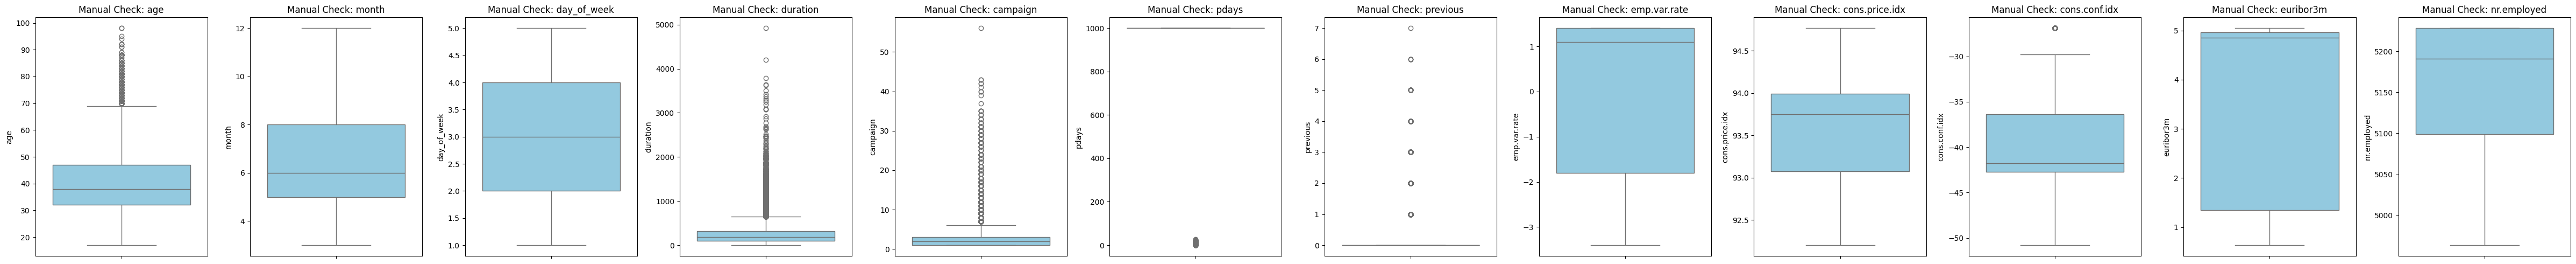

,Column,Outlier Count,Percentage (%)
0,age,469,1.14
1,month,0,0.00
2,day_of_week,0,0.00
3,duration,2963,7.19
4,campaign,2406,5.84
5,pdays,1515,3.68
6,previous,5625,13.66
7,emp.var.rate,0,0.00
8,cons.price.idx,0,0.00
9,cons.conf.idx,447,1.09


In [289]:
def detect_outliers(df, show_plots=True):

    numeric_cols = df.select_dtypes(include=[np.number]).columns
    summary_data = []

    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        count = len(outliers)

        summary_data.append({
            'Column': col,
            'Outlier Count': count,
            'Percentage (%)': round((count / len(df)) * 100, 2)
        })

    if show_plots:
        num_cols = len(numeric_cols)
        fig, axes = plt.subplots(1, num_cols, figsize=(num_cols * 4, 5))
        if num_cols == 1: axes = [axes]
        for i, col in enumerate(numeric_cols):
            sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
            axes[i].set_title(f'Manual Check: {col}')
        plt.tight_layout()
        plt.show()

    return pd.DataFrame(summary_data)

detect_outliers(df)

##  IsolationForest


In [290]:
def handle_outliers_isolation_forest(df, contamination = 0.05):

    df_cleaned = df.copy()

    numeric_cols = df.select_dtypes(include=[np.number]).columns

    if numeric_cols.empty:
        print("No numerical columns found.")
        return df_cleaned


    iso = IsolationForest(contamination=contamination, random_state=42)


    data_for_model = df[numeric_cols].fillna(df[numeric_cols].median())
    preds = iso.fit_predict(data_for_model)

    outlier_indices = df.index[preds == -1]
    df_cleaned = df_cleaned.drop(index=outlier_indices)

    print("\n----- Isolation Forest Summary -----")
    print(f"Total Rows Before: {len(df)}")
    print(f"Detected and Removed: {len(outlier_indices)} rows ({(len(outlier_indices)/len(df)*100):.2f}%)")
    print(f"Total Rows After: {len(df_cleaned)}")
    print("-" * 36)

    return df_cleaned

In [291]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  int64  
 9   day_of_week     41188 non-null  int64  
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

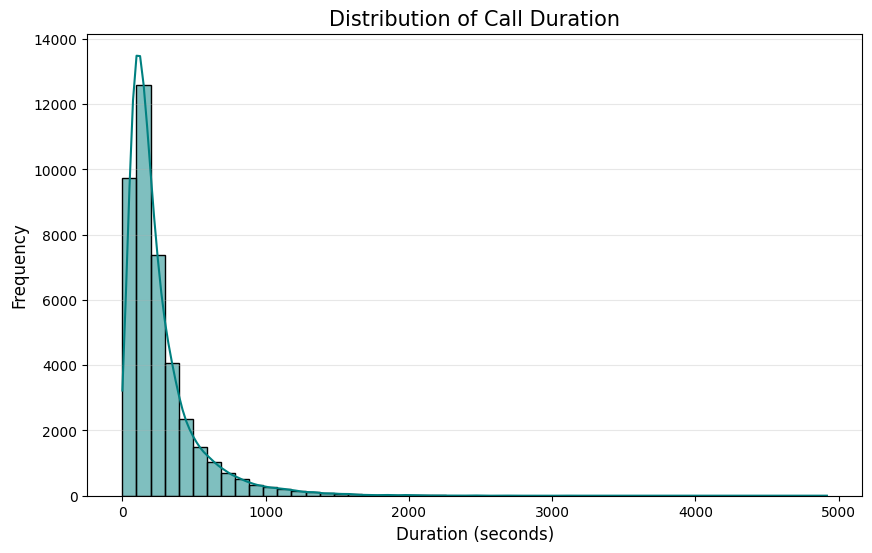

In [292]:
plt.figure(figsize=(10, 6))
sns.histplot(df['duration'], kde=True, color='teal', bins=50)
plt.title('Distribution of Call Duration', fontsize=15)
plt.xlabel('Duration (seconds)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

### After Islation Forest

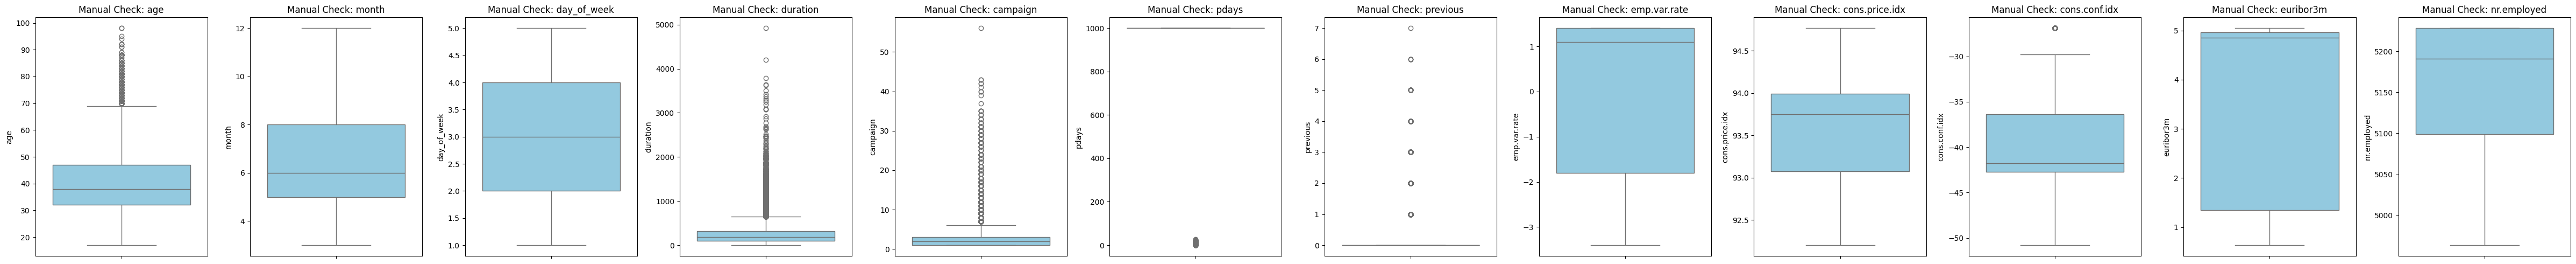

,Column,Outlier Count,Percentage (%)
0,age,469,1.14
1,month,0,0.00
2,day_of_week,0,0.00
3,duration,2963,7.19
4,campaign,2406,5.84
5,pdays,1515,3.68
6,previous,5625,13.66
7,emp.var.rate,0,0.00
8,cons.price.idx,0,0.00
9,cons.conf.idx,447,1.09


In [293]:
detect_outliers(df)

## Imputation
---

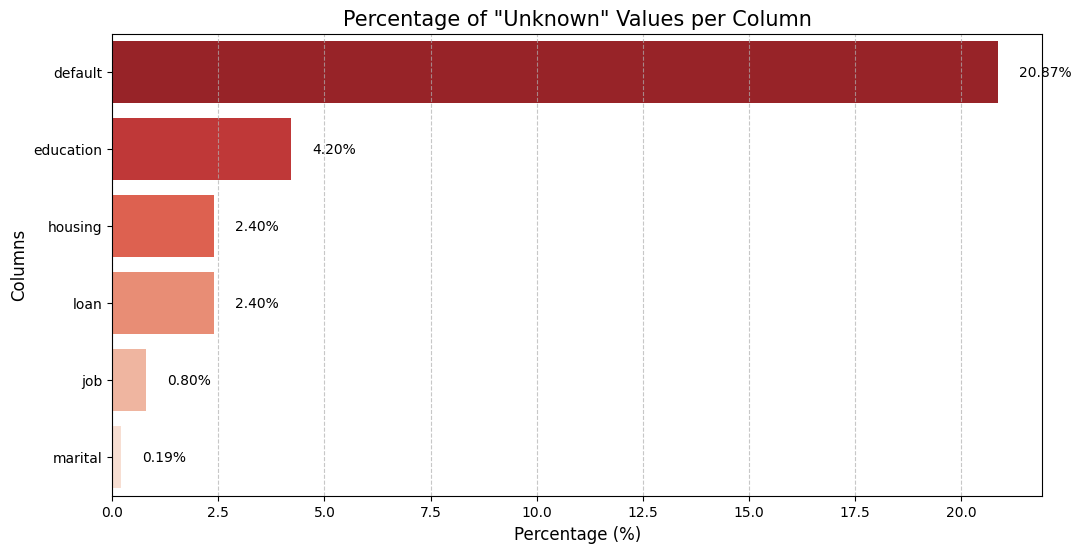

,Count,Percentage (%)
default,8597,20.87
education,1731,4.20
housing,990,2.40
loan,990,2.40
job,330,0.80
marital,80,0.19


In [294]:
def plot_unknown_values(df):

    unknown_counts = (df == 'unknown').sum()
    unknown_data = unknown_counts[unknown_counts > 0].sort_values(ascending=False)
    if unknown_data.empty:
        print("No 'unknown' values found in the dataset.")
        return
    unknown_pct = (unknown_data / len(df)) * 100
    plt.figure(figsize=(12, 6))
    sns.barplot(x=unknown_pct.values, y=unknown_pct.index, palette='Reds_r')
    for i, v in enumerate(unknown_pct.values):
        plt.text(v + 0.5, i, f'{v:.2f}%', color='black', va='center')
    plt.title('Percentage of "Unknown" Values per Column', fontsize=15)
    plt.xlabel('Percentage (%)', fontsize=12)
    plt.ylabel('Columns', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

    summary = pd.DataFrame({'Count': unknown_data, 'Percentage (%)': unknown_pct.round(2)})
    return summary

plot_unknown_values(df)

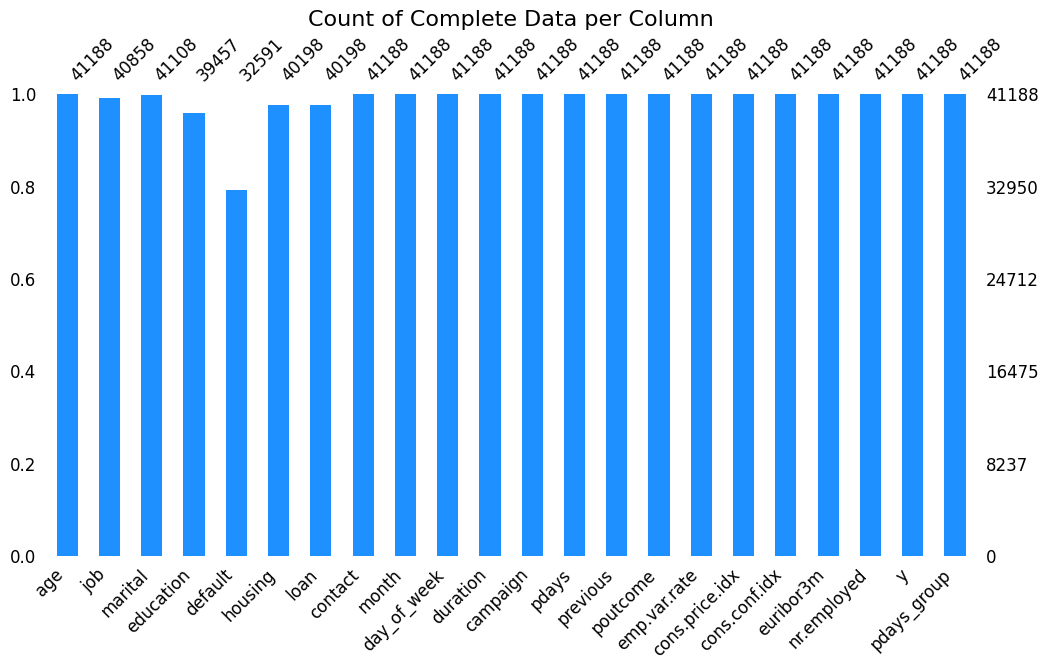

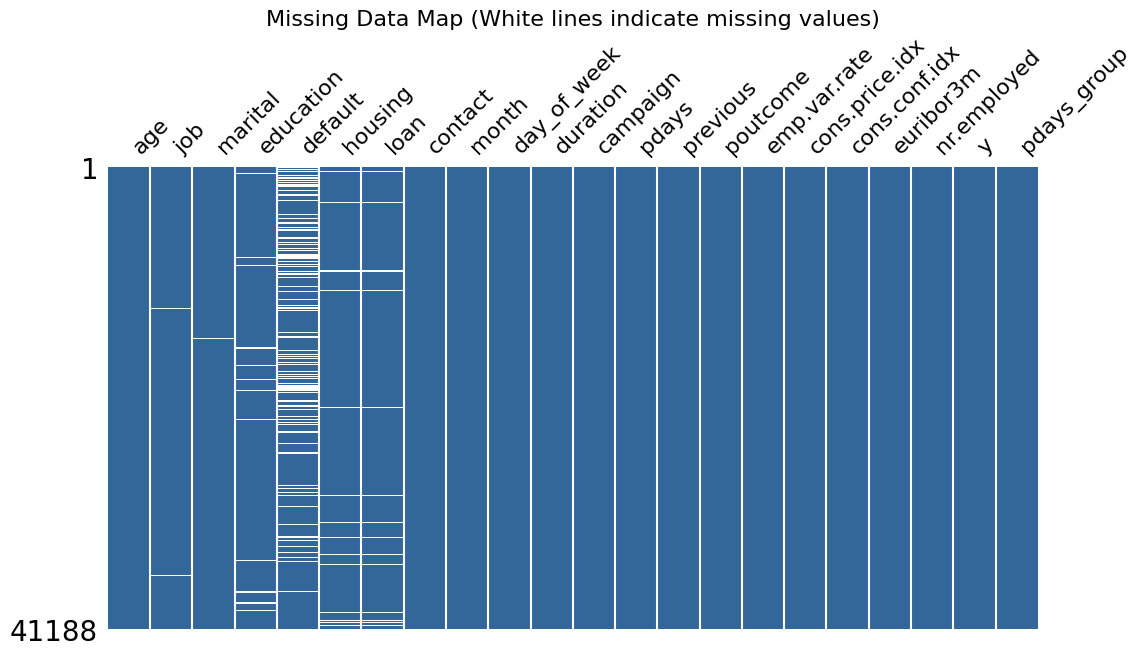

In [295]:
# 1. Convert 'unknown' strings to actual NaN values so the library can detect them
df.replace('unknown', np.nan, inplace=True)

# ==========================================
# Chart 1: Bar Chart
# Shows the total count of non-missing values per column
# ==========================================
msno.bar(df, figsize=(12, 6), color="dodgerblue", fontsize=12)
plt.title('Count of Complete Data per Column', fontsize=16)
plt.show()

# ==========================================
# Chart 2: Matrix Plot
# Excellent for seeing WHERE the missing values are and if they are related
# ==========================================
msno.matrix(df, figsize=(12, 6), color=(0.2, 0.4, 0.6), sparkline=False)
plt.title('Missing Data Map (White lines indicate missing values)', fontsize=16)
plt.show()

In [296]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

reverse_mappings = {}

for col in cat_cols:
    unique_vals = df[col].dropna().unique()
    mapping = {val: i for i, val in enumerate(unique_vals)}
    reverse_mappings[col] = {i: val for i, val in enumerate(unique_vals)}
    df[col] = df[col].map(mapping)

imputer = IterativeImputer(random_state=42, max_iter=10)
df.iloc[:, :] = imputer.fit_transform(df)

for col in cat_cols:
    df[col] = np.round(df[col])

    max_idx = len(reverse_mappings[col]) - 1
    df[col] = np.clip(df[col], 0, max_idx)

    df[col] = df[col].map(reverse_mappings[col])

print('Imputation using IterativeImputer is complete')

Imputation using IterativeImputer is complete


In [297]:
plot_unknown_values(df)

No 'unknown' values found in the dataset.


---
---
# EDA
---
---

## Information Dataset
---

In [298]:
df.shape

(41188, 22)

In [299]:
df.describe(include = 'all')

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,pdays_group
count,41188.00000,41188,41188,41188,41188,41188,41188,41188,41188.000000,41188.000000,...,41188.000000,41188.000000,41188,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188,41188
unique,NaN,11,3,7,2,2,2,2,NaN,NaN,...,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,2,5
top,NaN,admin,married,university degree,no,yes,no,cellular,NaN,NaN,...,NaN,NaN,nonexistent,NaN,NaN,NaN,NaN,NaN,no,not contacted
freq,NaN,10422,24961,12216,41185,22199,34940,26144,NaN,NaN,...,NaN,NaN,35563,NaN,NaN,NaN,NaN,NaN,36548,39673
mean,40.02406,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.607896,2.979581,...,962.475454,0.172963,NaN,0.081886,93.575664,-40.502600,3.621291,5167.035911,NaN,NaN
std,10.42125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.040998,1.411514,...,186.910907,0.494901,NaN,1.570960,0.578840,4.628198,1.734447,72.251528,NaN,NaN
min,17.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,1.000000,...,0.000000,0.000000,NaN,-3.400000,92.201000,-50.800000,0.634000,4963.600000,NaN,NaN
25%,32.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,2.000000,...,999.000000,0.000000,NaN,-1.800000,93.075000,-42.700000,1.344000,5099.100000,NaN,NaN
50%,38.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.000000,3.000000,...,999.000000,0.000000,NaN,1.100000,93.749000,-41.800000,4.857000,5191.000000,NaN,NaN
75%,47.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.000000,4.000000,...,999.000000,0.000000,NaN,1.400000,93.994000,-36.400000,4.961000,5228.100000,NaN,NaN


## Charts
---

### Visualizing the Target Variable Distribution (Class Balance)
The very first step in any classification project is to check the distribution of your target variable (`y`). We use a simple **Countplot** (bar chart) to see how many instances of 'yes' and 'no' exist.

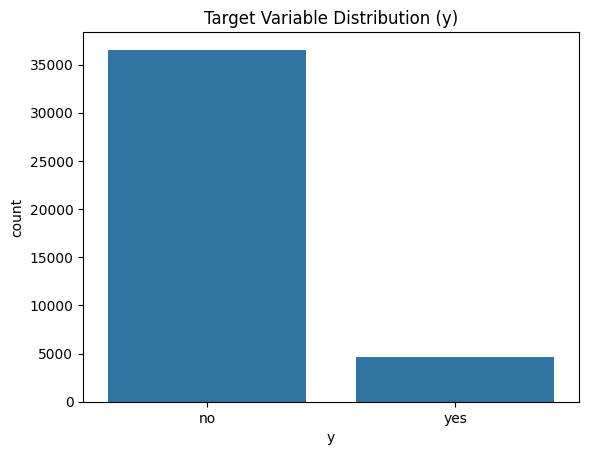

In [300]:
sns.countplot(x = 'y',data = df)
plt.title('Target Variable Distribution (y)')
plt.show()

### Visualizing Numerical Features and Outliers vs Target Variable
To understand how numerical features vary across the target classes (and to identify potential outliers), we use a grid of **Boxplots**. This allows us to see the median, spread, and extreme values of each feature for both the 'yes' and 'no' outcomes simultaneously.

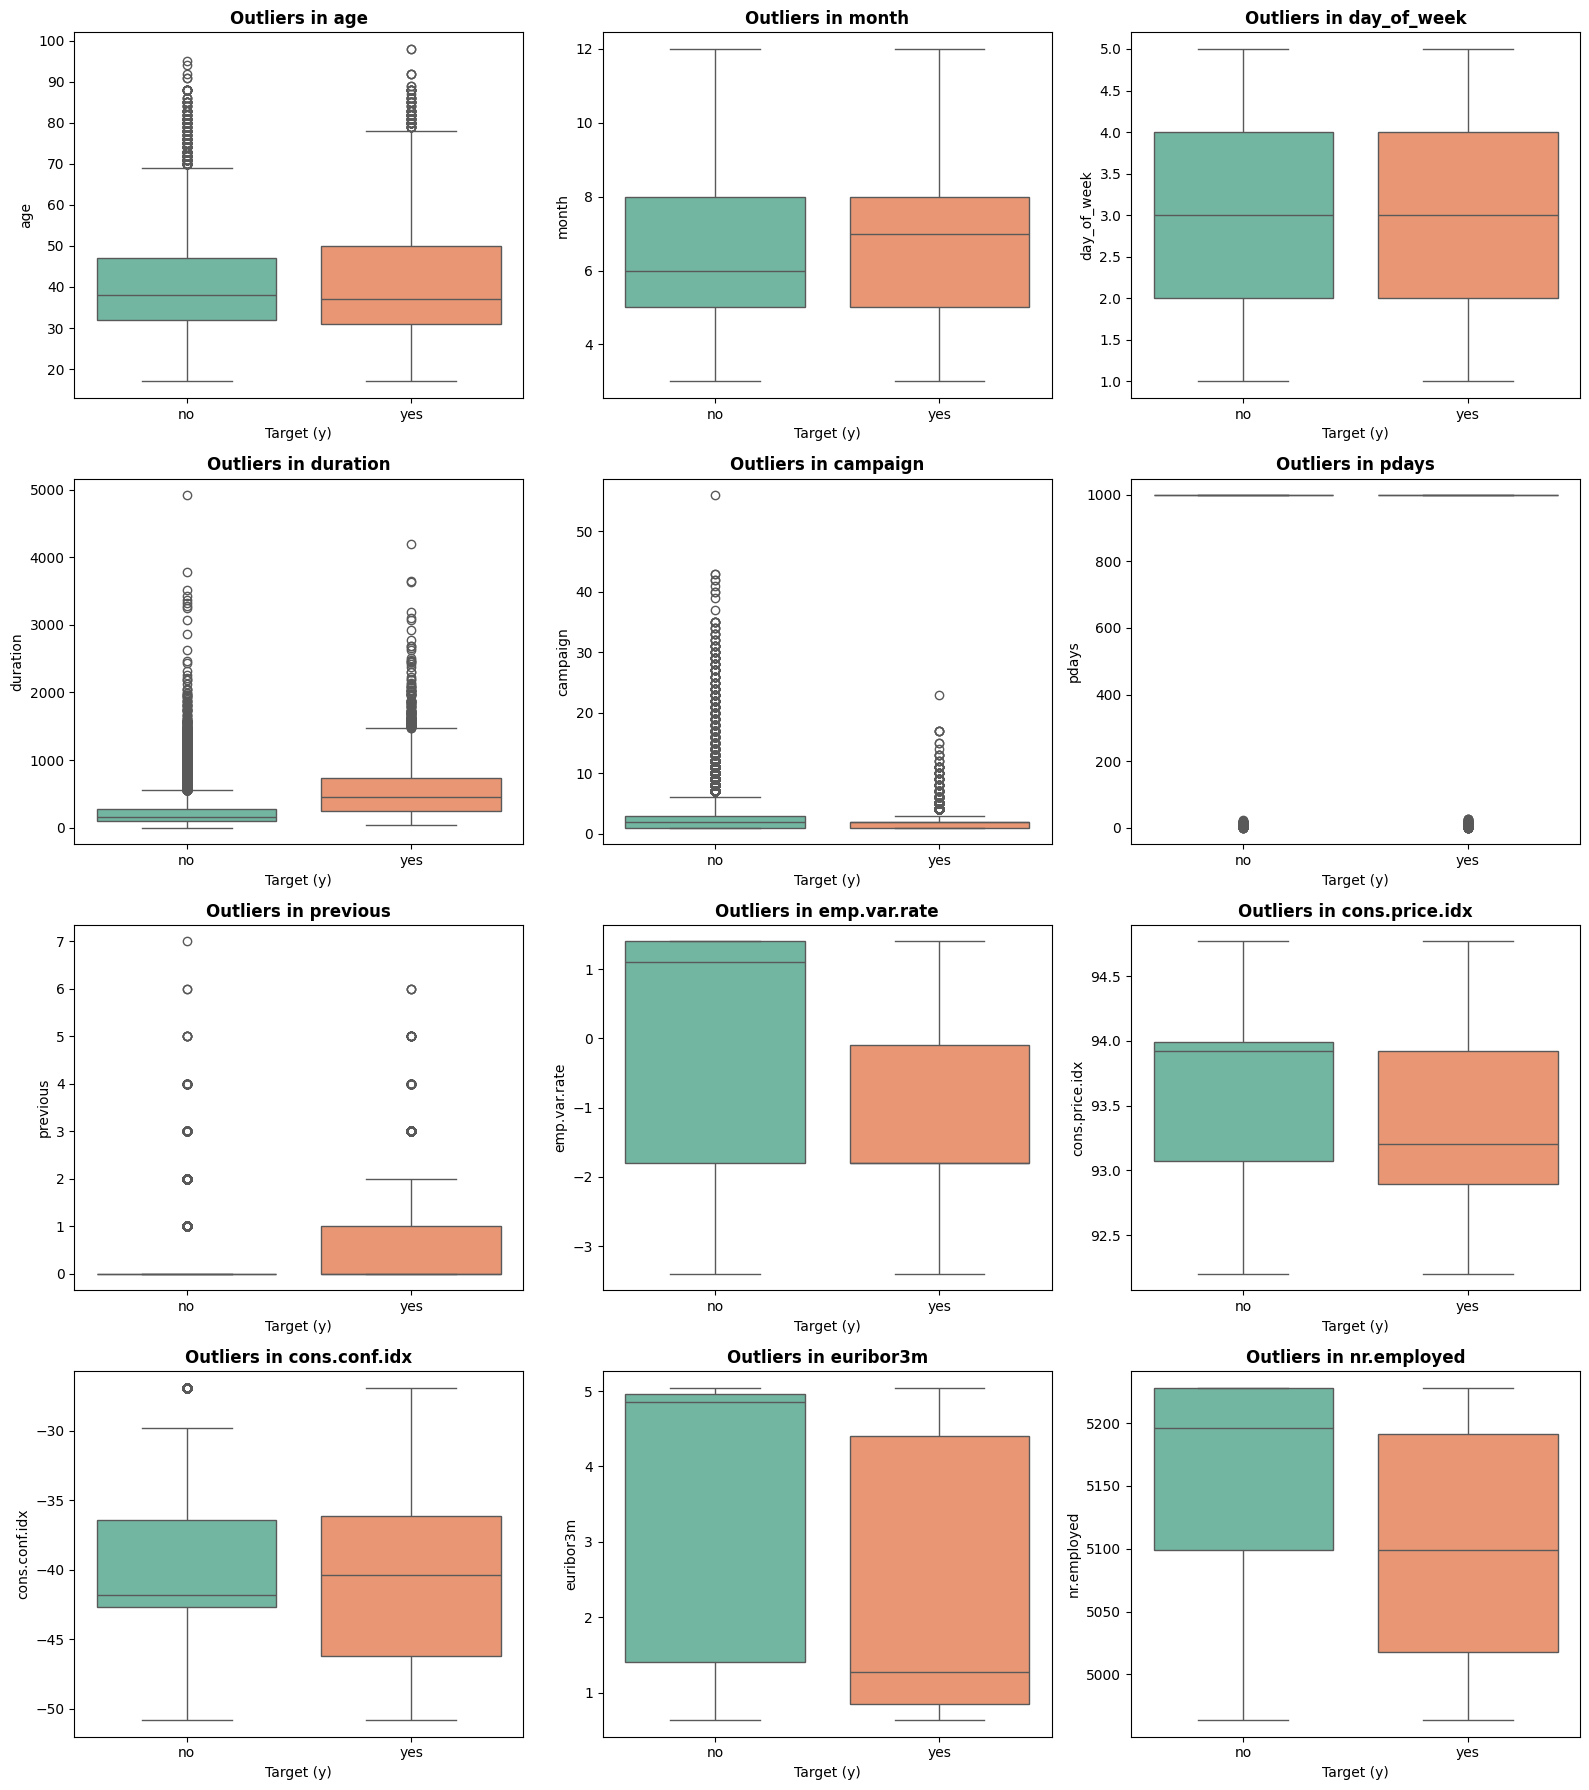

In [301]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(16, 18))
for i, col in enumerate(num_cols, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(x='y', y=col, data=df, palette='Set2')
    plt.title(f'Outliers in {col}', fontsize=12, fontweight='bold')
    plt.xlabel('Target (y)')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

### Visualizing Categorical Features vs Target Variable
To understand the relationship between categorical attributes and the target variable `y`, we use a grid of **Grouped Bar Charts**. This helps identify which categories have a higher conversion rate (e.g., which jobs or education levels are more likely to say "yes").

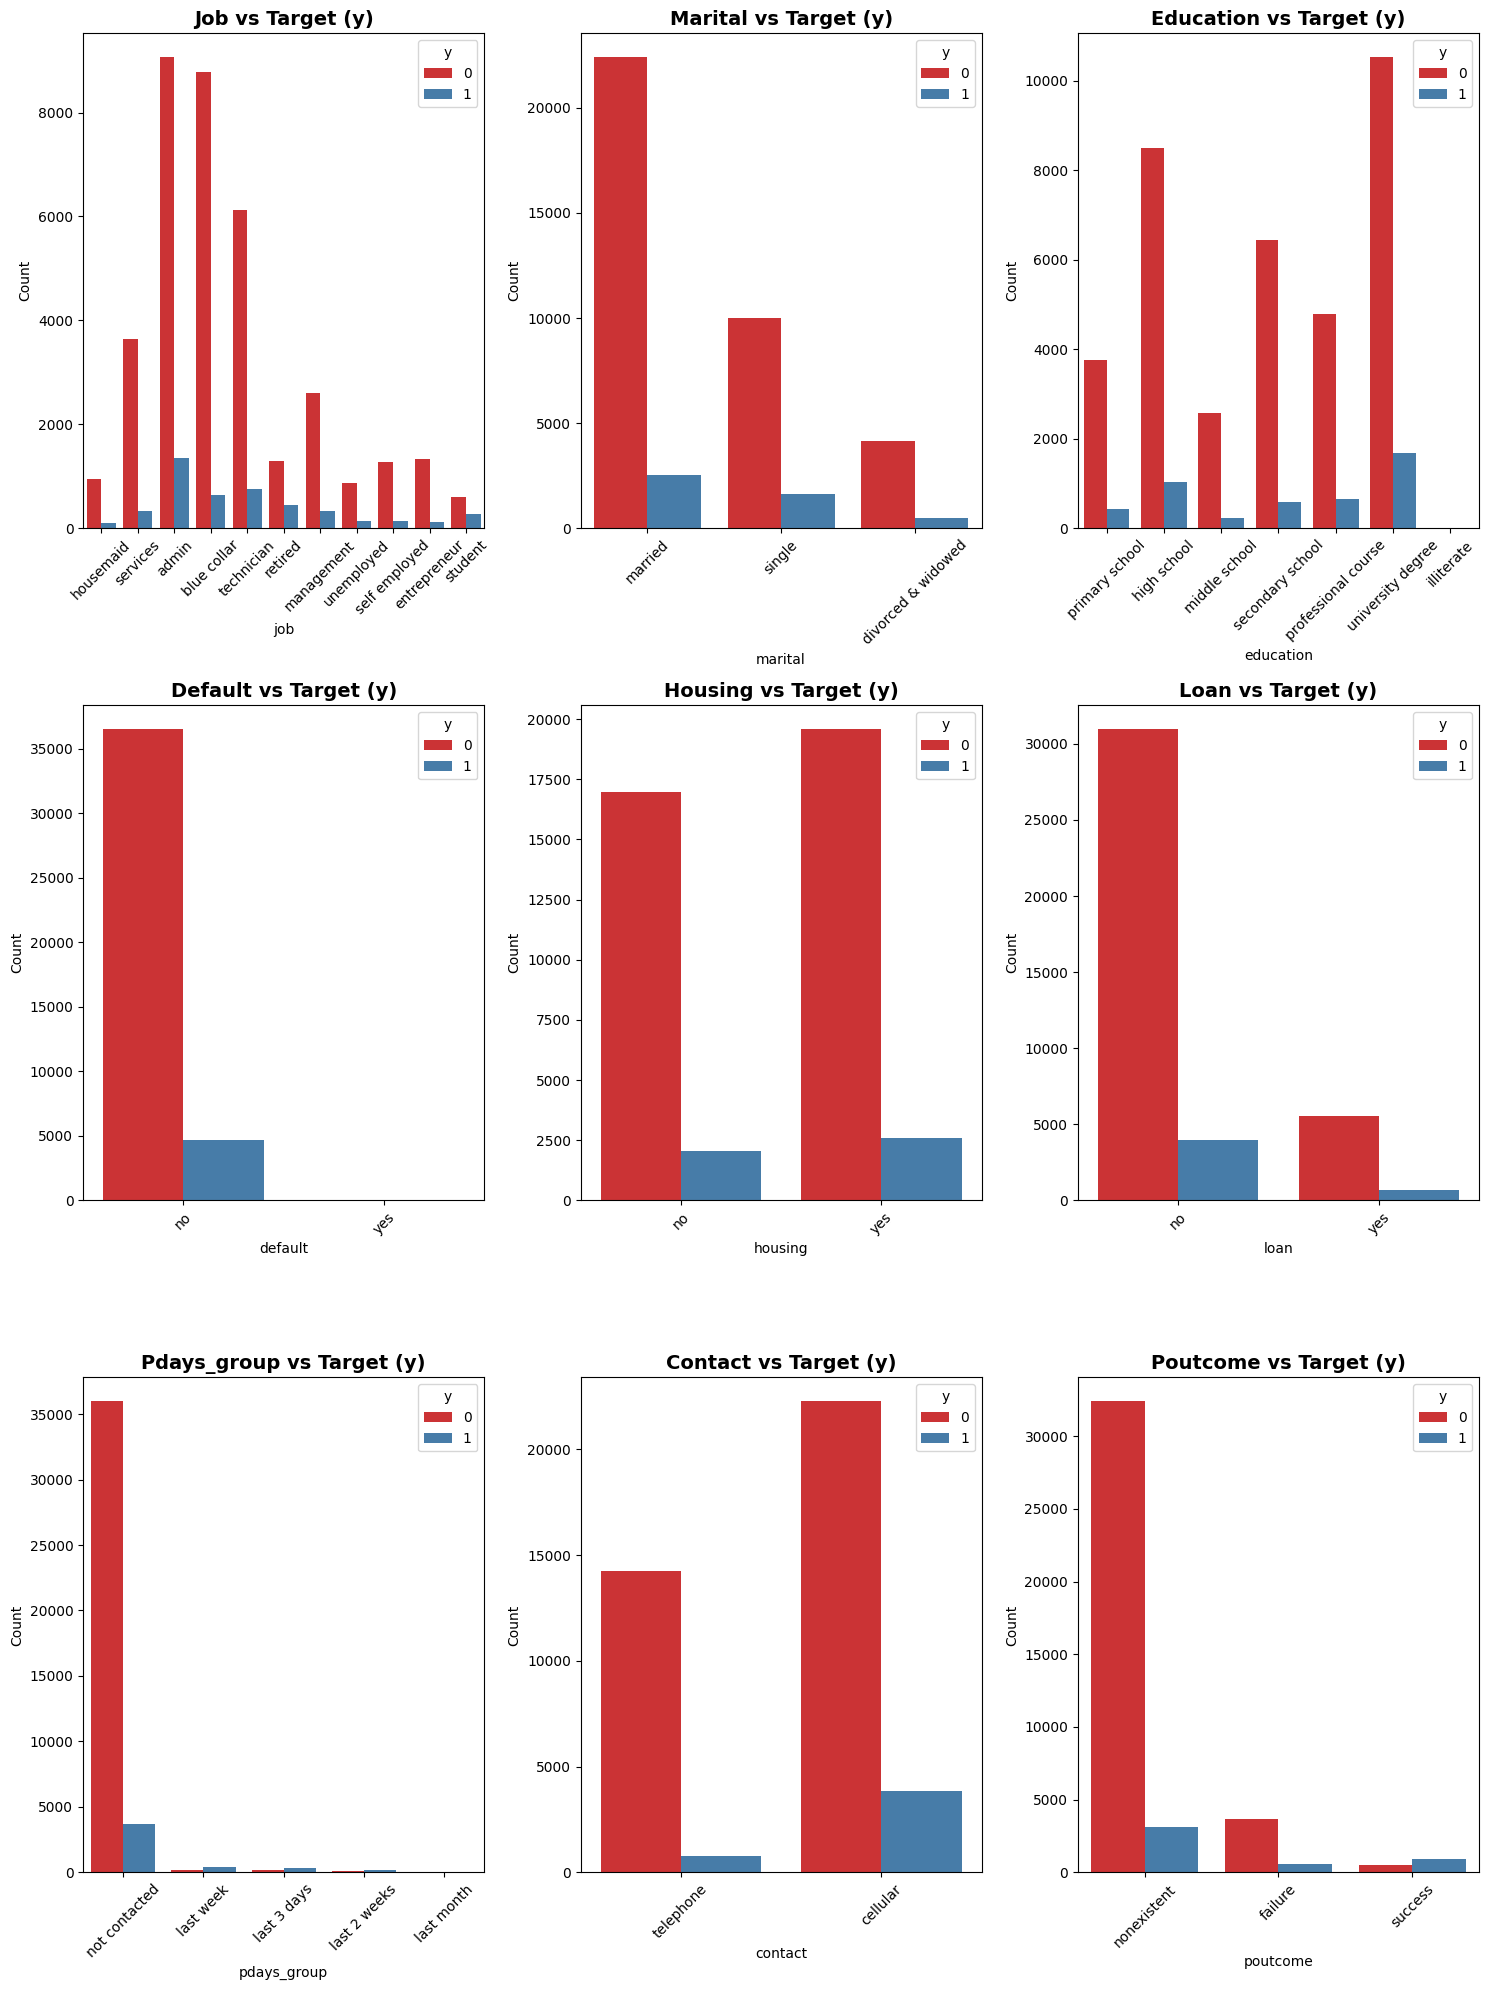

In [332]:
categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'pdays_group', 'contact', 'poutcome']

fig, axes = plt.subplots(3, 3, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, hue='y', data=df, ax=axes[i], palette='Set1')
    axes[i].set_title(f'{col.capitalize()} vs Target (y)', fontsize=14, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45) 
    axes[i].set_ylabel('Count')


plt.tight_layout()
plt.show()

### Visualizing Data Distributions (KDE Plots)
To understand the underlying distribution of our numerical features and see how well they separate our target classes, we use **Kernel Density Estimate (KDE) plots**. A KDE plot is like a smoothed histogram. If the curves for 'yes' and 'no' are heavily overlapping, the feature might not be very useful. If the peaks are separated, the feature is a strong predictor.

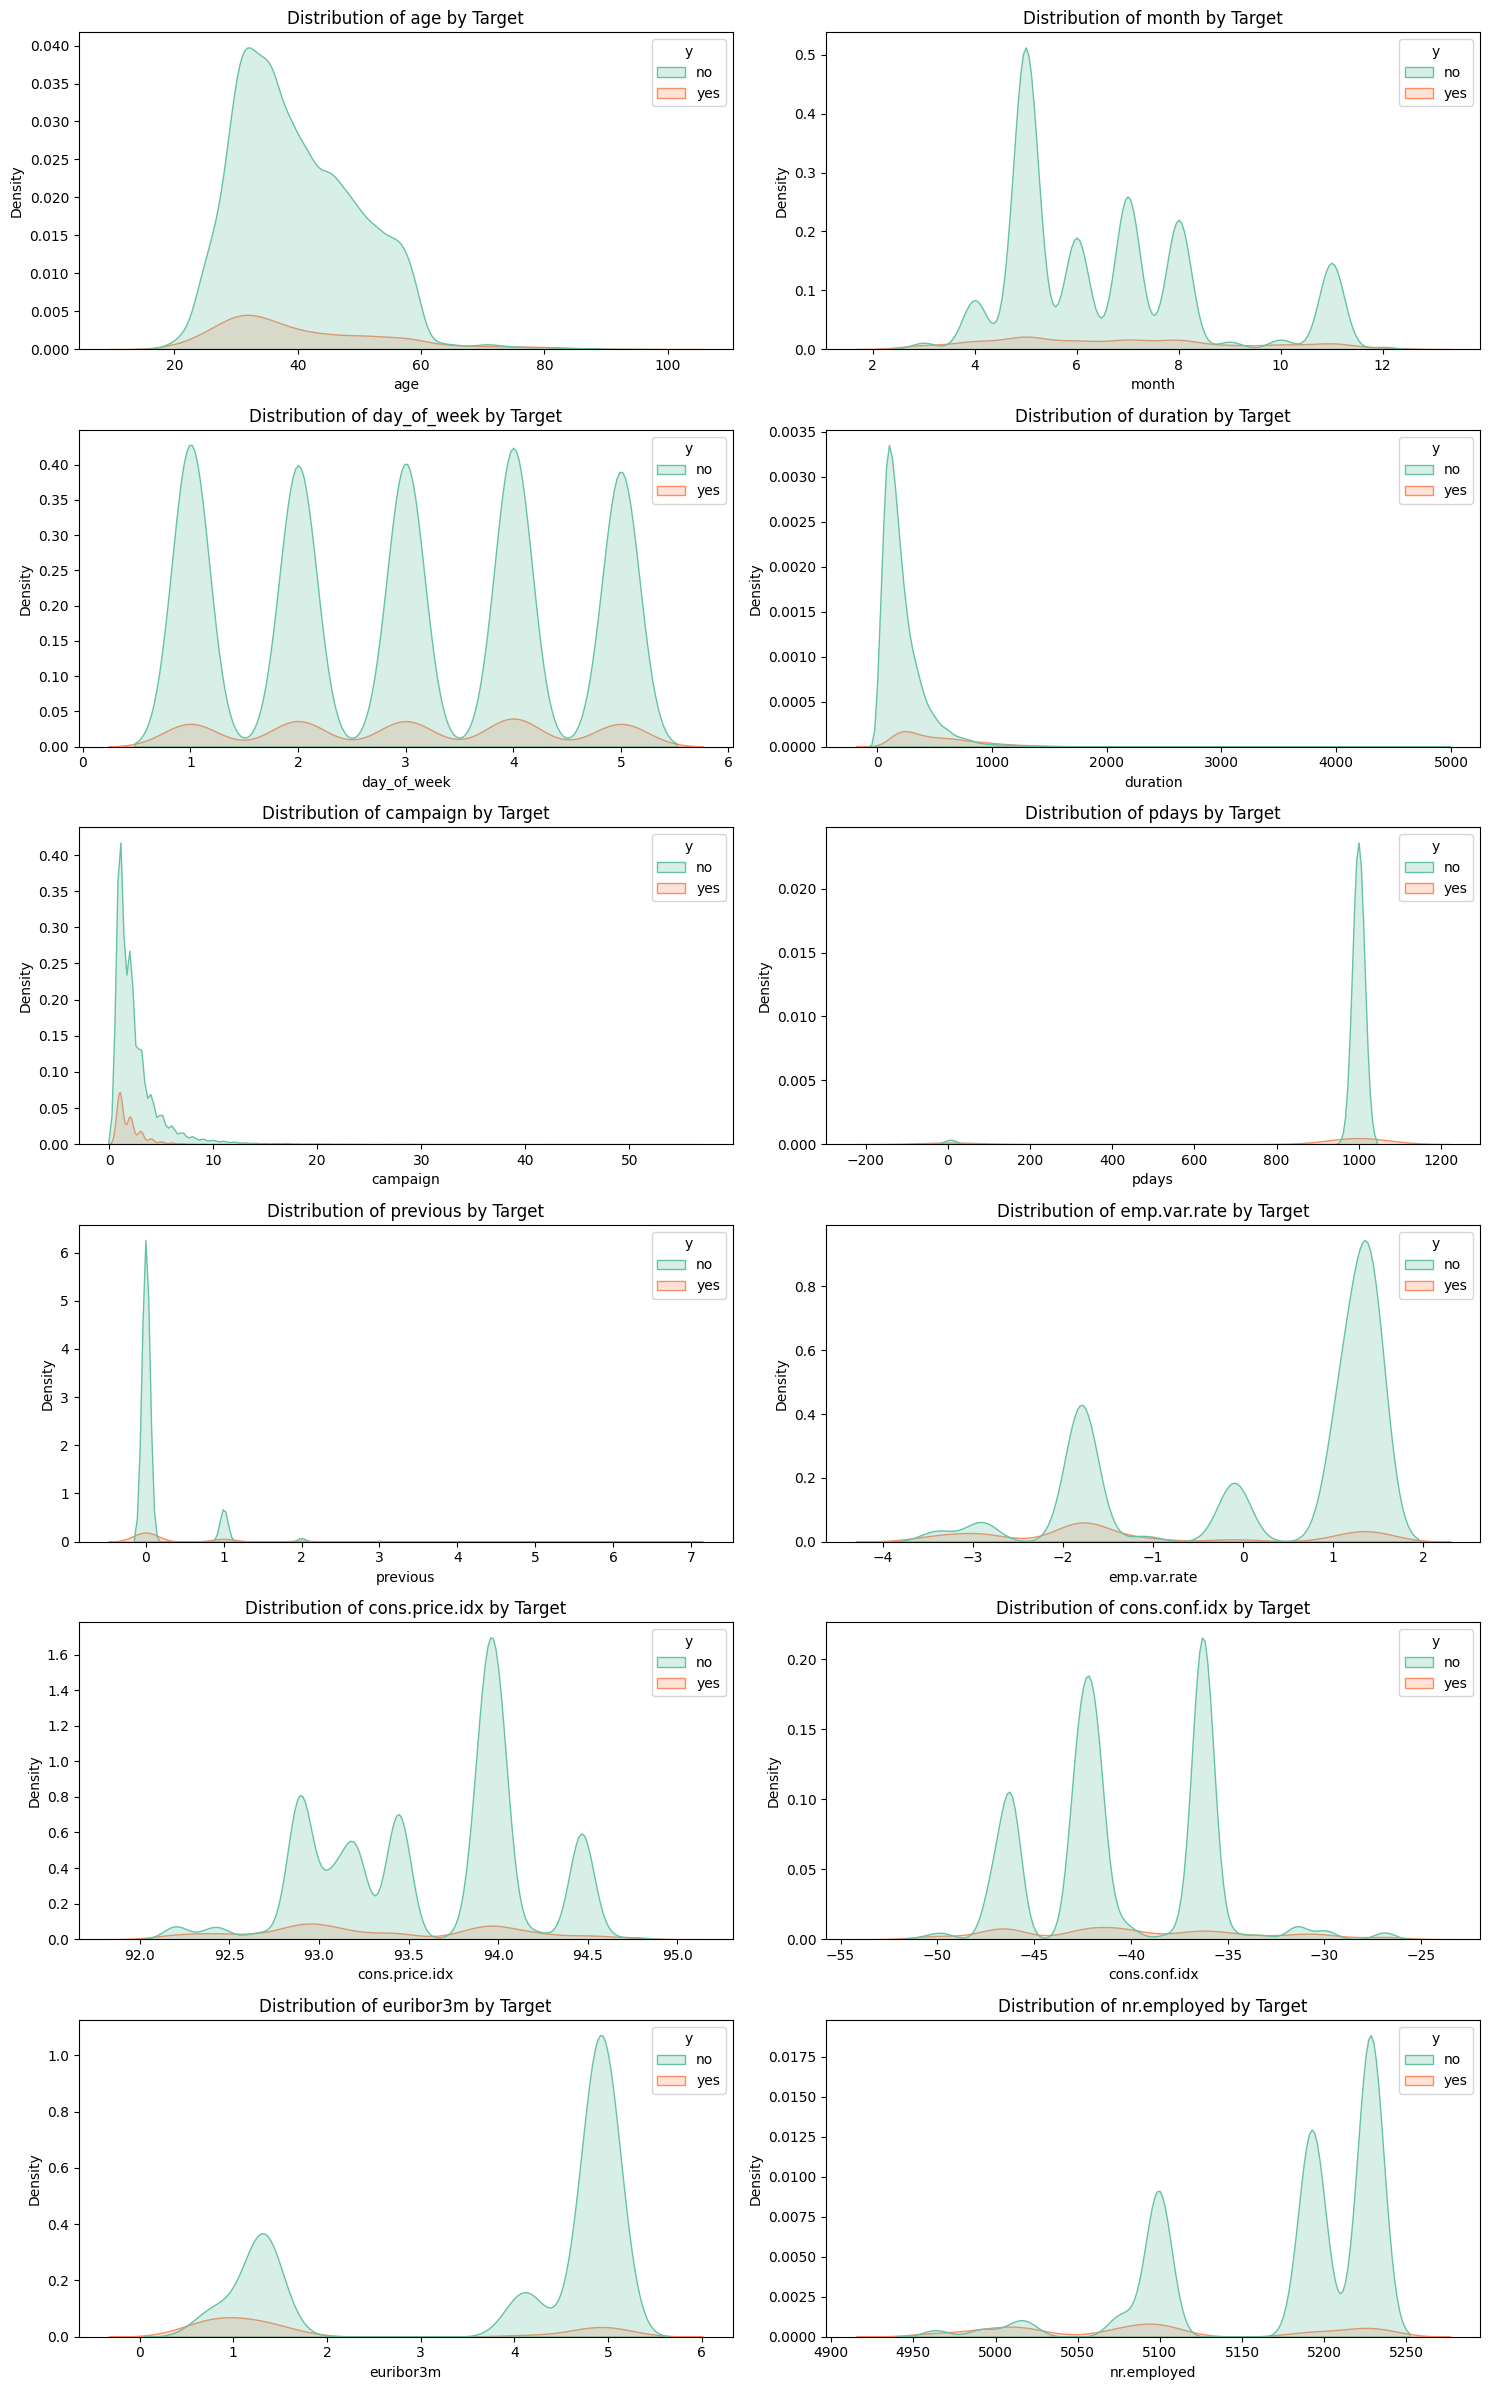

In [303]:
cols_per_row = 2
num_plots = len(num_cols)
num_rows = math.ceil(num_plots / cols_per_row)

fig, axes = plt.subplots(num_rows, cols_per_row, figsize=(15, num_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.kdeplot(
        data=df, 
        x=col, 
        hue='y', 
        fill=True, 
        palette='Set2', 
        ax=axes[i]
    )
    axes[i].set_title(f'Distribution of {col} by Target')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')

# Clean up: Remove empty subplots if num_plots is odd
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Visualizing Feature Correlation with the Target
To determine which numerical features have the strongest mathematical relationship with our target variable, we calculate the **Pearson Correlation Coefficient**.

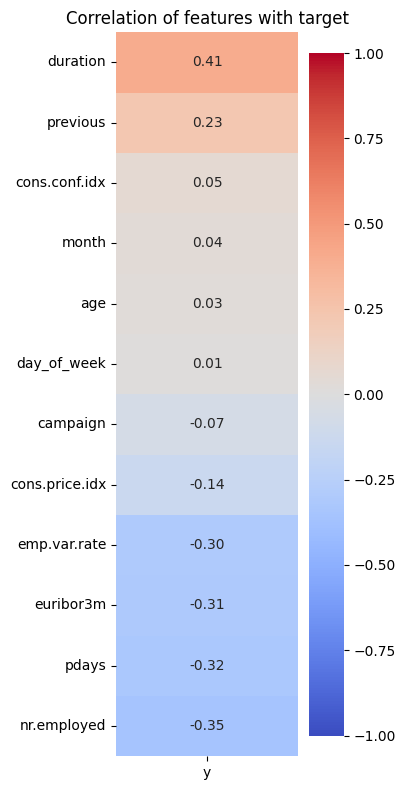

In [304]:
if df['y'].dtype == 'object':
    # .replace ensures values not in {'yes', 'no'} aren't nuked to NaN
    df['y'] = df['y'].replace({'no': 0, 'yes': 1}).astype(int)

corr = df.corr(numeric_only = True).drop('y')

matrix = corr[['y']].sort_values(by = 'y', ascending = False)

plt.figure(figsize = (4, 8))
sns.heatmap(matrix,
            annot = True,
            fmt = '.2f',
            cmap = 'coolwarm',
            vmin = -1,
            vmax = 1)
plt.title('Correlation of features with target')
plt.tight_layout()
plt.show()

### Dimensionality Reduction and Visualization (t-SNE)
To understand if our features contain natural patterns or clusters that separate the target classes, we use **t-SNE** (t-Distributed Stochastic Neighbor Embedding).

In [ ]:
df_viz = df.copy()

# Handle categorical features if any remain
X_viz = pd.get_dummies(df_viz.drop(columns=['y']), drop_first=True)
y_viz = df_viz['y']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_viz)

tsne = TSNE(n_components=2, 
            perplexity=30,
            max_iter=1000, 
            random_state=42, 
            init='pca', 
            learning_rate='auto')

X_tsne = tsne.fit_transform(X_scaled)

# Visualization
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_tsne[:, 0], 
    y=X_tsne[:, 1], 
    hue=y_viz, 
    palette='Set2', 
    alpha=0.6, 
    s=20,
    edgecolor='none'
)

plt.title('t-SNE Visualization of Feature Space')
plt.xlabel('t-SNE component 1')
plt.ylabel('t-SNE component 2')
plt.legend(title='Target (y)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Expirements

In [ ]:
X['has_loan'] = (X.loan == 'yes').astype(int)
X['ageXloan'] = X.age * X.has_loan
X['campaignXpdays'] = 

In [329]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  int64  
 9   day_of_week     41188 non-null  int64  
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

---
---
# Modeling
---
---

## Splitting/Encoding/Scaling
---

In [376]:
drop_cols = ['y', 'duration', 'pdays']
X = df.drop(columns = drop_cols)
y = df.y

ohe_cols = ['marital', 'housing', 'loan', 'poutcome', 'pdays_group', 'default', 'contact']
te_cols = ['job', 'education', 'month', 'day_of_week', 'euribor3m', 'emp.var.rate']
scale_cols = ['age', 'campaign', 'previous']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = .2,
    stratify = y,
    random_state = 30
)

print(f"Train size : {X_train.shape}")
print(f"Test size  : {X_test.shape}")
print(f"Class distribution : {np.bincount(y_test)}")

Train size : (32950, 19)
Test size  : (8238, 19)
Class distribution : [7310  928]


In [377]:
preprocessor = ColumnTransformer(
    transformers=[
        ('te', TargetEncoder(), te_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ohe_cols),
        ('num', RobustScaler(), scale_cols)
    ], remainder = 'passthrough')

print('Encodng & Scaling Complete')

Encodng & Scaling Complete


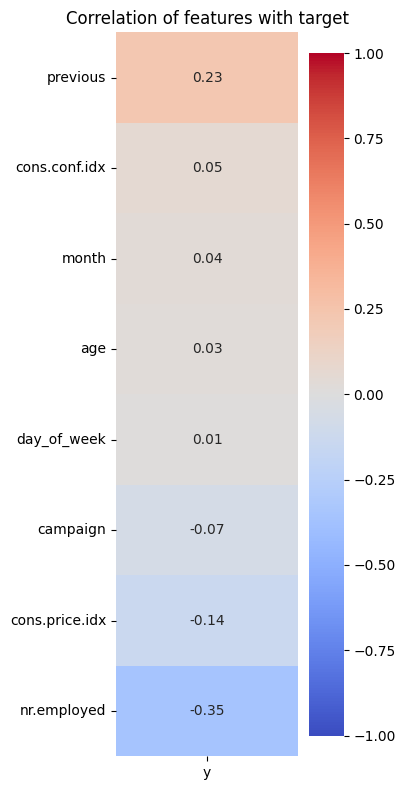

In [378]:
corr = df.corr(numeric_only = True).drop(['y', 'euribor3m', 'emp.var.rate', 'duration', 'pdays'])

matrix = corr[['y']].sort_values(by = 'y', ascending = False)

plt.figure(figsize = (4, 8))
sns.heatmap(matrix,
            annot = True,
            fmt = '.2f',
            cmap = 'coolwarm',
            vmin = -1,
            vmax = 1)
plt.title('Correlation of features with target')
plt.tight_layout()
plt.show()

## Checking Multicollineairty
---

In [379]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X_numeric = X.select_dtypes(include=[np.number]).dropna()
X_vif_input = add_constant(X_numeric)

# Build the VIF DataFrame
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif_input.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif_input.values, i) for i in range(X_vif_input.shape[1])]

# Sort and display (dropping the 'const' row for better readability)
vif_results = vif_data[vif_data["Feature"] != 'const'].sort_values(by="VIF", ascending=False)
print(vif_results)

           Feature        VIF
9        euribor3m  79.243321
6     emp.var.rate  34.994721
10     nr.employed  34.321101
7   cons.price.idx   7.031485
8    cons.conf.idx   2.683599
2            month   1.503203
5         previous   1.407902
4         campaign   1.033986
1              age   1.021878
3      day_of_week   1.001264


## Setting up model variables
---

In [380]:
# CONFIG
random_state = 30
n_splits     = 5
n_trials     = 50
scoring      = "recall"
thresholds = [.2, .25, .3, .35, .4, .45, .5]
results    = []
f2_scorer = make_scorer(fbeta_score, beta=2)

skf = StratifiedKFold(n_splits = n_splits, shuffle = True, random_state = random_state)

# Shared dict — each model block writes its proba here
test_proba = {}

## Logistic Regression
---

In [ ]:
# Optuna objective
def objective_lr(trial):
    params = {
        "C"           : trial.suggest_float("C", 0.001, 10.0, log = True),
        "max_iter"    : trial.suggest_int("max_iter", 200, 1000),
        "class_weight": trial.suggest_categorical("class_weight", [None, 'balanced']),
    }
    model = LogisticRegression(**params, random_state = 30)
    
    pipeline = Pipeline([
        ('scaler/encoder', preprocessor),
        ('classifier', model)
    ])
    
    # CV is run on the already-scaled train set
    return cross_val_score(pipeline, X_train, y_train,
                           cv = skf, scoring = f2_scorer, n_jobs=-1).mean()

study_lr = optuna.create_study(
    direction="maximize",
    sampler = optuna.samplers.TPESampler(seed = random_state)
)
study_lr.optimize(objective_lr, n_trials= n_trials, show_progress_bar = True)

print(f"\n✔ Best CV {f2_scorer} : {study_lr.best_value:.3f}")
print(f"  Best params      : {study_lr.best_params}")

# Refit on full train set with best params
lr_best = pipeline = Pipeline([
        ('scaler/encoder', preprocessor),
        ('classifier', LogisticRegression(**study_lr.best_params, random_state = random_state))
    ])
lr_best.fit(X_train, y_train)

lr_proba = lr_best.predict_proba(X_test)[:, 1]
lr_pred = lr_best.predict(X_test)
test_proba["Logistic Regression"] = lr_proba   # save for ROC-AUC plot

# Classification report
print("\n" + "-"*55)
print("  Classification Report:")
print(classification_report(y_test, lr_pred, digits = 2))
print("-"*55)

# Assuming a €5 cost per call attempt
cost_per_call = 5 
precision_class_1 = classification_report(y_test, lr_pred, output_dict = True)['1']['precision']
current_cost = cost_per_call / precision_class_1 if precision_class_1 > 0 else float('inf')

print(f"Economic Impact: €{current_cost:.2f} per subscriber")
print(f"Target Met: {current_cost < 35}")

Best trial: 16. Best value: 0.552106:  40%|████      | 20/50 [02:15<03:47,  7.59s/it]

-------------------------------------------------------
  Threshold optimization  (Maximise Recall)
-------------------------------------------------------
  Optimal threshold : 0.20
  Precision         : 0.12
  Recall            : 0.98
  F1                : 0.21

  Classification report at optimal threshold:
              precision    recall  f1-score   support

           0     0.9559    0.0475    0.0904      7310
           1     0.1158    0.9828    0.2072       928

    accuracy                         0.1528      8238
   macro avg     0.5359    0.5151    0.1488      8238
weighted avg     0.8613    0.1528    0.1036      8238


  All thresholds:


,threshold,precision,recall,f1
0,0.200,0.116,0.983,0.207
1,0.250,0.125,0.944,0.221
2,0.300,0.157,0.897,0.267
3,0.350,0.193,0.810,0.311
4,0.400,0.268,0.703,0.388
5,0.450,0.289,0.676,0.405
6,0.500,0.339,0.608,0.435


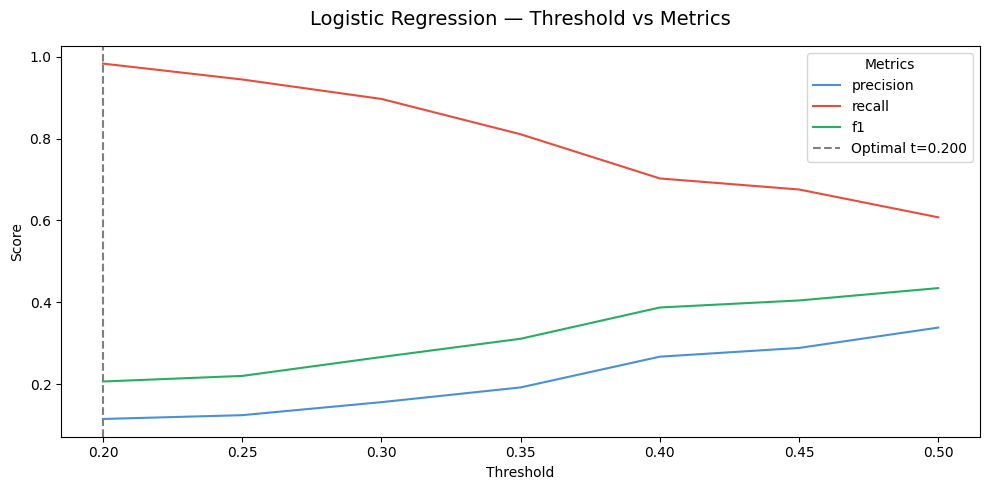

In [ ]:
# Threshold optimisation
results = []
for t in thresholds:
    preds = (lr_proba >= t).astype(int)
    results.append({
        "threshold": t,
        "precision": precision_score(y_test, preds, zero_division = 0),
        "recall"   : recall_score(y_test,    preds, zero_division = 0),
        "f1"       : f1_score(y_test,        preds, zero_division = 0),
    })

df_lr_thresh = pd.DataFrame(results)
best_lr = df_lr_thresh.loc[df_lr_thresh["recall"].idxmax()]

print("-"*55)
print("  Threshold optimization  (Maximise Recall)")
print("-"*55)
print(f"  Optimal threshold : {best_lr['threshold']:.2f}")
print(f"  Precision         : {best_lr['precision']:.2f}")
print(f"  Recall            : {best_lr['recall']:.2f}")
print(f"  F1                : {best_lr['f1']:.2f}")

print("\n  Classification report at optimal threshold:")
lr_preds_opt = (lr_proba >= best_lr["threshold"]).astype(int)
print(classification_report(y_test, lr_preds_opt, digits=4))

# ── All thresholds table ──────────────────────────────────
print("\n  All thresholds:")
display(
    df_lr_thresh.style
    .highlight_max(subset=["recall"],    color="#f5a9a9")
    .highlight_max(subset=["f1"],        color="#a9f5b0")
    .highlight_max(subset=["precision"], color="#a9c8f5")
    .format("{:.3f}")
)

df_plot = df_lr_thresh.melt(id_vars = 'threshold', 
                            value_vars = ['precision', 'recall', 'f1'],
                            var_name = 'Metric', 
                            value_name = 'Score')

# Precision / Recall curve for this model
plt.figure(figsize=(10, 5))
ax = sns.lineplot(data = df_plot,
                  x = 'threshold',
                  y = 'Score',
                  hue = 'Metric', 
                  palette = {'precision': '#4A90D9', 'recall': '#E74C3C', 'f1': '#27AE60'})
plt.axvline(best_lr["threshold"], color="gray", linestyle="--", 
            label=f"Optimal t={best_lr['threshold']:.3f}")

plt.title("Logistic Regression — Threshold vs Metrics", fontsize=14, pad=15)
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend(title="Metrics", frameon=True)
plt.tight_layout()
plt.show()

## Random Forest
---

In [ ]:
# Optuna objective
def objective_rf(trial):
    params = {
        "n_estimators"     : trial.suggest_int("n_estimators", 100, 500),
        "max_depth"        : trial.suggest_int("max_depth", 3, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf" : trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features"     : trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        "class_weight"     : trial.suggest_categorical("class_weight", [None, 'balanced']),
    }
    model = RandomForestClassifier(**params, random_state = random_state, n_jobs=-1)
    
    pipeline = Pipeline([
        ('scaler/encoder', preprocessor),
        ('classifier', model)
    ])
    
    return cross_val_score(pipeline, X_train, y_train,
                           cv = skf, scoring = f2_scorer, n_jobs=-1).mean()

study_rf = optuna.create_study(
    direction = "maximize",
    sampler=optuna.samplers.TPESampler(seed = random_state)
)
study_rf.optimize(objective_rf, n_trials = n_trials, show_progress_bar = True)

print(f"\n✔ Best CV {f2_scorer} : {study_rf.best_value:.3f}")
print(f"  Best params      : {study_rf.best_params}")

# Refit on full train set with best params
rf_best = pipeline = Pipeline([
        ('scaler/encoder', preprocessor),
        ('classifier', RandomForestClassifier(**study_rf.best_params, random_state = random_state, n_jobs=-1))
    ])
rf_best.fit(X_train, y_train)

rf_proba = rf_best.predict_proba(X_test)[:, 1]
rf_pred = lr_best.predict(X_test)
test_proba["Random Forest"] = rf_proba   # save for ROC-AUC plot

# Classification report
print("\n" + "-"*55)
print("  Classification Report")
print(classification_report(y_test, rf_pred, digits = 2))
print("-"*55)

# Assuming a €5 cost per call attempt
cost_per_call = 5 
precision_class_1 = classification_report(y_test, rf_pred, output_dict = True)['1']['precision']
current_cost = cost_per_call / precision_class_1 if precision_class_1 > 0 else float('inf')

print(f"Economic Impact: €{current_cost:.2f} per subscriber")
print(f"Target Met: {current_cost < 35}")

Best trial: 48. Best value: 0.549927: 100%|██████████| 50/50 [04:43<00:00,  5.67s/it]



✔ Best CV make_scorer(fbeta_score, response_method='predict', beta=2) : 0.550
  Best params      : {'n_estimators': 214, 'max_depth': 11, 'min_samples_split': 17, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'class_weight': 'balanced'}

-------------------------------------------------------
  Classification Report
              precision    recall  f1-score   support

           0       0.94      0.85      0.89      7310
           1       0.34      0.61      0.44       928

    accuracy                           0.82      8238
   macro avg       0.64      0.73      0.66      8238
weighted avg       0.88      0.82      0.84      8238

-------------------------------------------------------
Economic Impact: €14.76 per subscriber
Target Met: True


═══════════════════════════════════════════════════════
  THRESHOLD OPTIMISATION  (Maximise Recall)
═══════════════════════════════════════════════════════
  Optimal threshold : 0.200
  Precision         : 0.1291
  Recall            : 0.9591
  F1                : 0.2276

  Classification report at optimal threshold:
              precision    recall  f1-score   support

           0      0.972     0.179     0.302      7310
           1      0.129     0.959     0.228       928

    accuracy                          0.267      8238
   macro avg      0.550     0.569     0.265      8238
weighted avg      0.877     0.267     0.294      8238


  All thresholds:


,threshold,precision,recall,f1
0,0.200,0.129,0.959,0.228
1,0.250,0.151,0.905,0.259
2,0.300,0.180,0.839,0.297
3,0.350,0.258,0.741,0.383
4,0.400,0.325,0.669,0.437
5,0.450,0.383,0.630,0.477
6,0.500,0.424,0.600,0.497


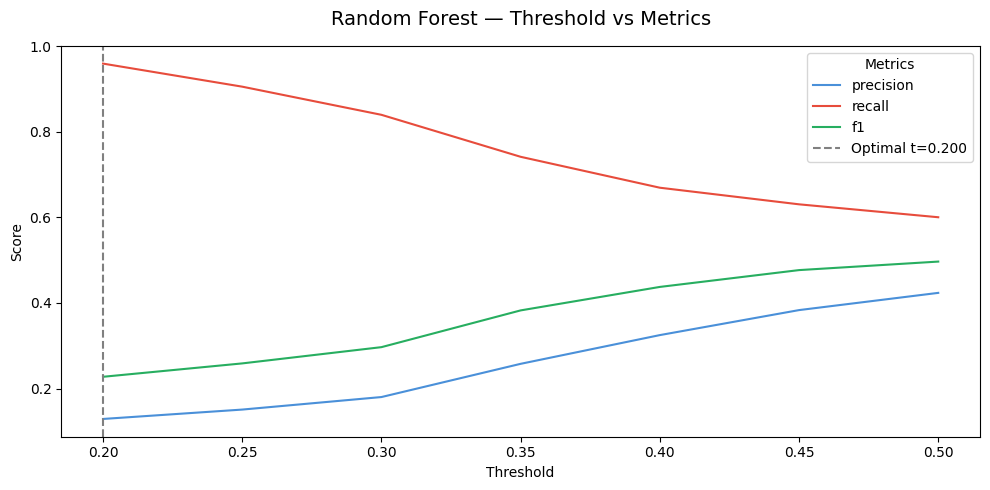

In [ ]:
# Threshold optimisation
results = []  # ← reset before every loop

for t in thresholds:
    preds = (rf_proba >= t).astype(int)
    results.append({
        "threshold": t,
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall"   : recall_score(y_test,    preds, zero_division=0),
        "f1"       : f1_score(y_test,        preds, zero_division=0),
    })

df_rf_thresh = pd.DataFrame(results)
best_rf      = df_rf_thresh.loc[df_rf_thresh["recall"].idxmax()]

print("═"*55)
print("  THRESHOLD OPTIMISATION  (Maximise Recall)")
print("═"*55)
print(f"  Optimal threshold : {best_rf['threshold']:.3f}")
print(f"  Precision         : {best_rf['precision']:.4f}")
print(f"  Recall            : {best_rf['recall']:.4f}")
print(f"  F1                : {best_rf['f1']:.4f}")

print("\n  Classification report at optimal threshold:")
rf_preds_opt = (rf_proba >= best_rf["threshold"]).astype(int)
print(classification_report(y_test, rf_preds_opt, digits = 3))

# ── All thresholds table ──────────────────────────────────
print("\n  All thresholds:")
display(
    df_rf_thresh.style
    .highlight_max(subset=["recall"],    color="#f5a9a9")
    .highlight_max(subset=["f1"],        color="#a9f5b0")
    .highlight_max(subset=["precision"], color="#a9c8f5")
    .format("{:.3f}")
)

df_plot = df_rf_thresh.melt(id_vars = 'threshold', 
                            value_vars = ['precision', 'recall', 'f1'],
                            var_name = 'Metric', 
                            value_name = 'Score')

# Precision / Recall curve for this model
plt.figure(figsize=(10, 5))
ax = sns.lineplot(data = df_plot,
                  x = 'threshold',
                  y = 'Score',
                  hue = 'Metric', 
                  palette = {'precision': '#4A90D9', 'recall': '#E74C3C', 'f1': '#27AE60'})
plt.axvline(best_rf["threshold"], color="gray", linestyle="--", 
            label=f"Optimal t={best_rf['threshold']:.3f}")

plt.title("Random Forest — Threshold vs Metrics", fontsize=14, pad=15)
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend(title="Metrics", frameon=True)
plt.tight_layout()
plt.show()

## XGBoost Classifier
---

In [ ]:
# Optuna objective
def objective_xgb(trial):
    params = {
        "n_estimators"    : trial.suggest_int("n_estimators", 100, 500),
        "max_depth"       : trial.suggest_int("max_depth", 3, 10),
        "learning_rate"   : trial.suggest_float("learning_rate", 0.001, 0.3, log = True),
        "subsample"       : trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha"       : trial.suggest_float("reg_alpha", 0.0001, 10.0, log = True),
        "reg_lambda"      : trial.suggest_float("reg_lambda", 0.0001, 10.0, log = True),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1.0, 10.0)
    }    
    model = XGBClassifier(
        **params, random_state = random_state,
        eval_metric="logloss", verbosity=0, n_jobs=-1
    )
    
    pipeline = Pipeline([
        ('scaler/encoder', preprocessor),
        ('classifier', model)
    ])

    return cross_val_score(pipeline, X_train, y_train,
                           cv = skf, scoring = f2_scorer, n_jobs=-1).mean()

study_xgb = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed = random_state)
)
study_xgb.optimize(objective_xgb, n_trials = n_trials, show_progress_bar = True)

print(f"\n✔ Best CV {f2_scorer} : {study_xgb.best_value:.2f}")
print(f"  Best params      : {study_xgb.best_params}")

# Refit on full train set with best params
xgb_best = pipeline = Pipeline([
        ('scaler/encoder', preprocessor),
        ('classifier', XGBClassifier(**study_xgb.best_params, random_state = random_state, eval_metric="logloss", verbosity=0, n_jobs=-1))
    ])
xgb_best.fit(X_train, y_train)
xgb_pred = xgb_best.predict(X_test)
xgb_proba = xgb_best.predict_proba(X_test)[:, 1]

test_proba["XGBoost"] = xgb_proba   # save for ROC-AUC plot

# Classification report
print("\n" + "-"*55)
print("  Classification Report:")
print(classification_report(y_test, xgb_pred, digits = 2))
print("-"*55)

# Assuming a €5 cost per call attempt
cost_per_call = 5 
precision_class_1 = classification_report(y_test, xgb_pred, output_dict = True)['1']['precision']
current_cost = cost_per_call / precision_class_1 if precision_class_1 > 0 else float('inf')

print(f"Economic Impact: €{current_cost:.2f} per subscriber")
print(f"Target Met: {current_cost < 35}")

Best trial: 41. Best value: 0.554137: 100%|██████████| 50/50 [03:12<00:00,  3.86s/it]



✔ Best CV make_scorer(fbeta_score, response_method='predict', beta=2) : 0.55
  Best params      : {'n_estimators': 409, 'max_depth': 3, 'learning_rate': 0.033778016082822264, 'subsample': 0.5433412040650363, 'colsample_bytree': 0.7790436704323369, 'reg_alpha': 0.2528535408132155, 'reg_lambda': 4.50417875856692, 'scale_pos_weight': 8.624441524927745}

-------------------------------------------------------
  Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.85      0.90      7310
           1       0.36      0.64      0.46       928

    accuracy                           0.83      8238
   macro avg       0.65      0.75      0.68      8238
weighted avg       0.88      0.83      0.85      8238

-------------------------------------------------------
Economic Impact: €14.03 per subscriber
Target Met: True


═══════════════════════════════════════════════════════
  Threshold Optimization  (Maximise Recall)
═══════════════════════════════════════════════════════
  Optimal threshold : 0.20
  Precision         : 0.12
  Recall            : 0.97
  F1                : 0.21

  Classification report at optimal threshold:
              precision    recall  f1-score   support

           0      0.967     0.095     0.174      7310
           1      0.120     0.974     0.214       928

    accuracy                          0.194      8238
   macro avg      0.543     0.535     0.194      8238
weighted avg      0.871     0.194     0.178      8238


  All thresholds:


,threshold,precision,recall,f1
0,0.200,0.120,0.974,0.214
1,0.250,0.137,0.930,0.239
2,0.300,0.156,0.887,0.265
3,0.350,0.194,0.812,0.313
4,0.400,0.254,0.733,0.378
5,0.450,0.314,0.683,0.431
6,0.500,0.356,0.641,0.458


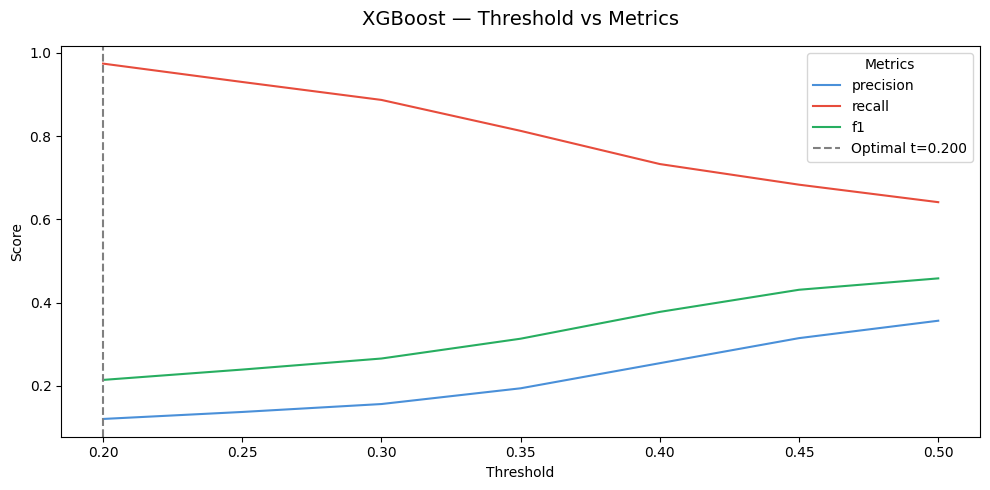

In [ ]:
# Threshold optimisation
results = []
for t in thresholds:
    preds = (xgb_proba >= t).astype(int)
    results.append({
        "threshold": t,
        "precision": precision_score(y_test, preds, zero_division = 0),
        "recall"   : recall_score(y_test,    preds, zero_division = 0),
        "f1"       : f1_score(y_test,        preds, zero_division = 0),
    })

df_xgb_thresh = pd.DataFrame(results)
best_xgb      = df_xgb_thresh.loc[df_xgb_thresh["recall"].idxmax()]

print("═"*55)
print("  Threshold Optimization  (Maximise Recall)")
print("═"*55)
print(f"  Optimal threshold : {best_xgb['threshold']:.2f}")
print(f"  Precision         : {best_xgb['precision']:.2f}")
print(f"  Recall            : {best_xgb['recall']:.2f}")
print(f"  F1                : {best_xgb['f1']:.2f}")

print("\n  Classification report at optimal threshold:")
xgb_preds_opt = (xgb_proba >= best_xgb["threshold"]).astype(int)
print(classification_report(y_test, xgb_preds_opt, digits = 3))

# ── All thresholds table ──────────────────────────────────
print("\n  All thresholds:")
display(
    df_xgb_thresh.style
    .highlight_max(subset=["recall"],    color="#f5a9a9")
    .highlight_max(subset=["f1"],        color="#a9f5b0")
    .highlight_max(subset=["precision"], color="#a9c8f5")
    .format("{:.3f}")
)

df_plot = df_xgb_thresh.melt(id_vars = 'threshold', 
                            value_vars = ['precision', 'recall', 'f1'],
                            var_name = 'Metric', 
                            value_name = 'Score')

# Precision / Recall curve for this model
plt.figure(figsize=(10, 5))
ax = sns.lineplot(data = df_plot,
                  x = 'threshold',
                  y = 'Score',
                  hue = 'Metric', 
                  palette = {'precision': '#4A90D9', 'recall': '#E74C3C', 'f1': '#27AE60'})
plt.axvline(best_xgb["threshold"], color="gray", linestyle="--", 
            label=f"Optimal t={best_xgb['threshold']:.3f}")

plt.title("XGBoost — Threshold vs Metrics", fontsize=14, pad=15)
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend(title="Metrics", frameon=True)
plt.tight_layout()
plt.show()

## LightGBM Classifier
---

In [ ]:
# Optuna objective
def objective_lgbm(trial):
    params = {
        "n_estimators"    : trial.suggest_int("n_estimators", 100, 500),
        "max_depth"       : trial.suggest_int("max_depth", 3, 12),
        "learning_rate"   : trial.suggest_float("learning_rate", 0.001, 0.3, log = True),
        "num_leaves"      : trial.suggest_int("num_leaves", 20, 150),
        "subsample"       : trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha"       : trial.suggest_float("reg_alpha", 0.0001, 10.0, log = True),
        "reg_lambda"      : trial.suggest_float("reg_lambda", 0.0001, 10.0, log = True),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1.0, 10.0)
    }
    model = LGBMClassifier(**params, random_state = random_state, n_jobs=-1, verbose=-1)
    
    pipeline = Pipeline([
        ('scaler/encoder', preprocessor),
        ('classifier', model)
    ])
    
    return cross_val_score(pipeline, X_train, y_train,
                           cv = skf, scoring = scoring, n_jobs=-1).mean()

study_lgbm = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed = random_state)
)
study_lgbm.optimize(objective_lgbm, n_trials = n_trials, show_progress_bar = True)

print(f"\n✔ Best CV {scoring} : {study_lgbm.best_value:.3f}")
print(f"  Best params      : {study_lgbm.best_params}")

# Refit on full train set with best params
lgbm_best = pipeline = Pipeline([
        ('scaler/encoder', preprocessor),
        ('classifier', LGBMClassifier(**study_lgbm.best_params, random_state = random_state, n_jobs=-1, verbose=-1))
    ])
lgbm_best.fit(X_train, y_train)

lgbm_proba = lgbm_best.predict_proba(X_test)[:, 1]
lgbm_pred = lgbm_best.predict(X_test)
test_proba["LightGBM"] = lgbm_proba   # save for ROC plot

# Classification report
print("\n" + "-"*55)
print("  Classification Report:")
print(classification_report(y_test, lgbm_pred, digits = 2))
print("-"*55)

# Assuming a €5 cost per call attempt
cost_per_call = 5 
precision_class_1 = classification_report(y_test, lgbm_pred, output_dict = True)['1']['precision']
current_cost = cost_per_call / precision_class_1 if precision_class_1 > 0 else float('inf')

print(f"Economic Impact: €{current_cost:.2f} per subscriber")
print(f"Target Met: {current_cost < 35}")

Best trial: 32. Best value: 0.629852: 100%|██████████| 50/50 [01:35<00:00,  1.90s/it]



✔ Best CV recall : 0.630
  Best params      : {'n_estimators': 127, 'max_depth': 3, 'learning_rate': 0.2796678124105683, 'num_leaves': 123, 'subsample': 0.7937276429999524, 'colsample_bytree': 0.5009399780665914, 'reg_alpha': 0.2699341537119526, 'reg_lambda': 9.97022388572772, 'class_weight': 'balanced'}

-------------------------------------------------------
  Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.87      0.91      7310
           1       0.39      0.63      0.48       928

    accuracy                           0.85      8238
   macro avg       0.67      0.75      0.69      8238
weighted avg       0.89      0.85      0.86      8238

-------------------------------------------------------
Economic Impact: €12.89 per subscriber
Target Met: True


-------------------------------------------------------
  Threshold Optimization  (Maximise Recall)
-------------------------------------------------------
  Optimal threshold : 0.200
  Precision         : 0.131
  Recall            : 0.946
  F1                : 0.230

  Classification report at optimal threshold:
              precision    recall  f1-score   support

           0     0.9675    0.2037    0.3365      7310
           1     0.1311    0.9461    0.2302       928

    accuracy                         0.2873      8238
   macro avg     0.5493    0.5749    0.2834      8238
weighted avg     0.8733    0.2873    0.3246      8238


  All thresholds:


,threshold,precision,recall,f1
0,0.200,0.131,0.946,0.230
1,0.250,0.151,0.889,0.259
2,0.300,0.184,0.842,0.302
3,0.350,0.231,0.755,0.354
4,0.400,0.294,0.693,0.413
5,0.450,0.344,0.650,0.450
6,0.500,0.388,0.628,0.480


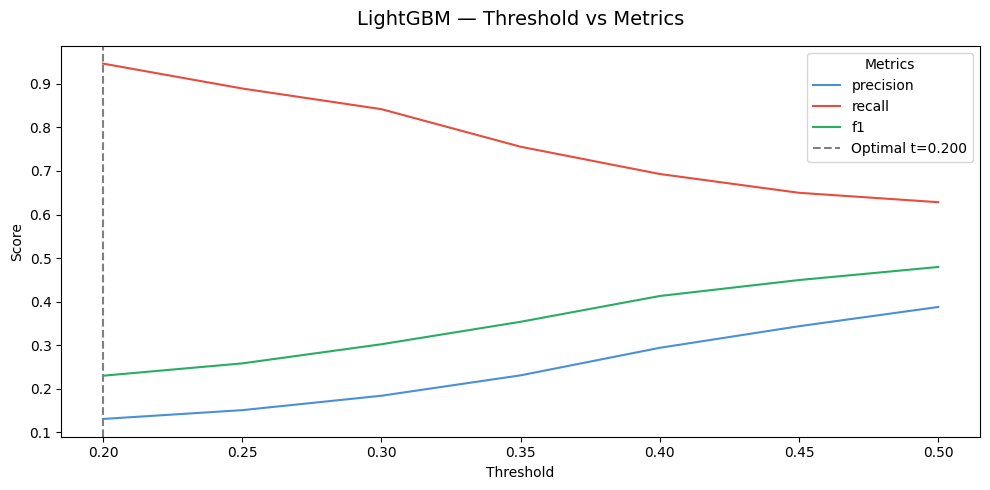

In [ ]:
# Threshold optimisation
results = []
for t in thresholds:
    preds = (lgbm_proba >= t).astype(int)
    results.append({
        "threshold": t,
        "precision": precision_score(y_test, preds, zero_division = 0),
        "recall"   : recall_score(y_test,    preds, zero_division = 0),
        "f1"       : f1_score(y_test,        preds, zero_division = 0),
    })

df_lgbm_thresh = pd.DataFrame(results)
best_lgbm      = df_lgbm_thresh.loc[df_lgbm_thresh["recall"].idxmax()]

print("-"*55)
print("  Threshold Optimization  (Maximise Recall)")
print("-"*55)
print(f"  Optimal threshold : {best_lgbm['threshold']:.3f}")
print(f"  Precision         : {best_lgbm['precision']:.3f}")
print(f"  Recall            : {best_lgbm['recall']:.3f}")
print(f"  F1                : {best_lgbm['f1']:.3f}")

print("\n  Classification report at optimal threshold:")
lgbm_preds_opt = (lgbm_proba >= best_lgbm["threshold"]).astype(int)
print(classification_report(y_test, lgbm_preds_opt, digits=4))

# ── All thresholds table ──────────────────────────────────
print("\n  All thresholds:")
display(
    df_lgbm_thresh.style
    .highlight_max(subset=["recall"],    color="#f5a9a9")
    .highlight_max(subset=["f1"],        color="#a9f5b0")
    .highlight_max(subset=["precision"], color="#a9c8f5")
    .format("{:.3f}")
)

df_plot = df_lgbm_thresh.melt(id_vars = 'threshold', 
                            value_vars = ['precision', 'recall', 'f1'],
                            var_name = 'Metric', 
                            value_name = 'Score')

# Precision / Recall curve for this model
plt.figure(figsize=(10, 5))
ax = sns.lineplot(data = df_plot,
                  x = 'threshold',
                  y = 'Score',
                  hue = 'Metric', 
                  palette = {'precision': '#4A90D9', 'recall': '#E74C3C', 'f1': '#27AE60'})
plt.axvline(best_lgbm["threshold"], color="gray", linestyle="--", 
            label=f"Optimal t={best_lgbm['threshold']:.3f}")

plt.title("LightGBM — Threshold vs Metrics", fontsize=14, pad=15)
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend(title="Metrics", frameon=True)
plt.tight_layout()
plt.show()

## ROC-AUC Chart
---

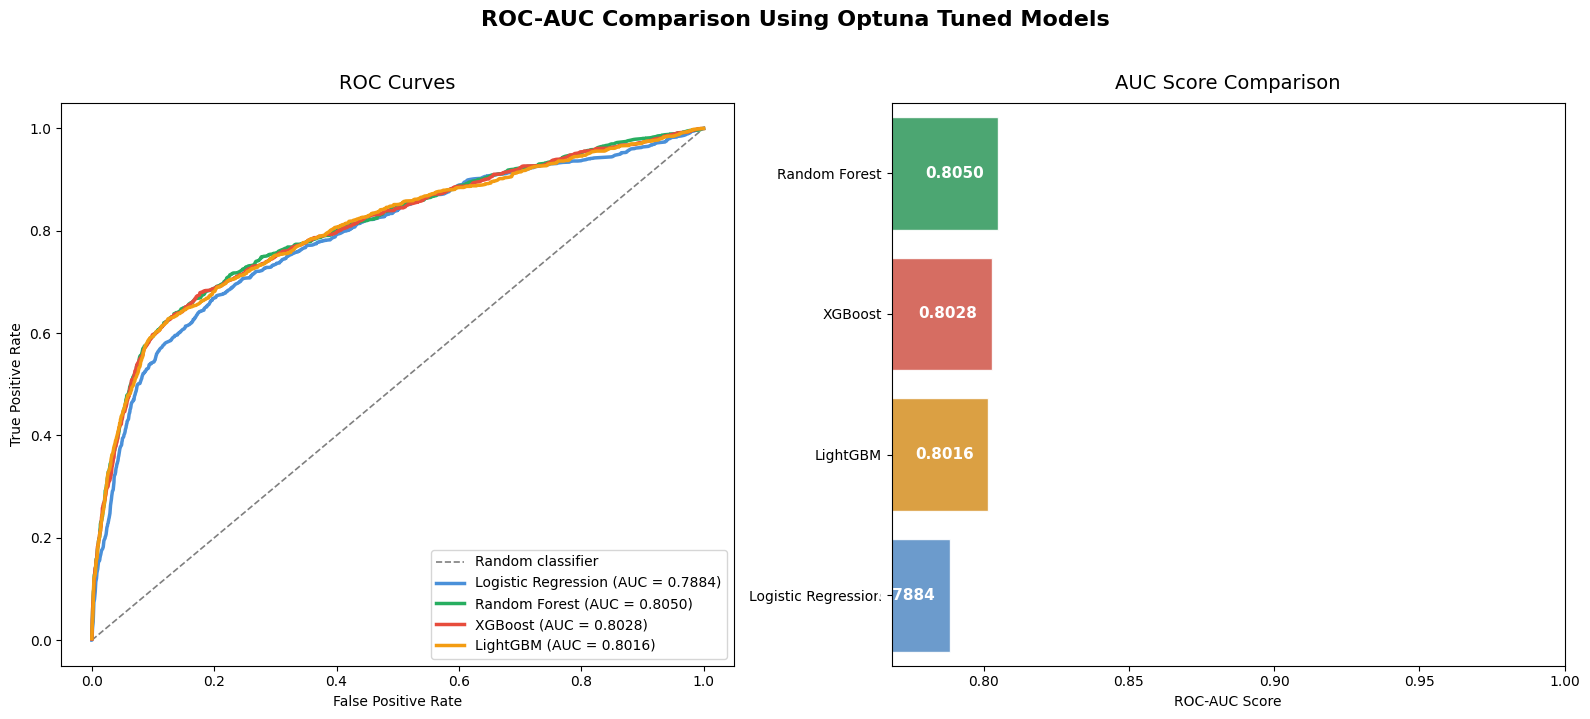


RANK  MODEL                TEST AUC  
----------------------------------------
1     Random Forest        0.8050    
2     XGBoost              0.8028    
3     LightGBM             0.8016    
4     Logistic Regression  0.7884    


In [ ]:
COLORS = {
    "Logistic Regression": "#4A90D9",
    "Random Forest": "#27AE60",
    "XGBoost": "#E74C3C",
    "LightGBM": "#F39C12",
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("ROC-AUC Comparison Using Optuna Tuned Models", 
             fontsize=16, fontweight="bold", y=1.02)

# 1. LEFT: ROC Curves (Matplotlib + Seaborn Styling)
ax = axes[0]
ax.plot([0, 1], [0, 1], "k--", lw=1.2, label="Random classifier", alpha=0.5)

# Calculate AUCs for the leaderboard and plot simultaneously
rows = []
for name, proba in test_proba.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    score = auc(fpr, tpr)
    rows.append({"Model": name, "AUC": score})
    
    # Plotting line
    sns.lineplot(x=fpr, y=tpr, ax=ax, lw=2.5, color=COLORS[name],
                 label=f"{name} (AUC = {score:.4f})")

ax.set_title("ROC Curves", fontsize=14, pad=10)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right", frameon=True)

# 2. RIGHT: AUC Bar Chart (Seaborn)
ax2 = axes[1]
df_aucs = pd.DataFrame(rows).sort_values("AUC", ascending=False)

sns.barplot(data=df_aucs, x='AUC', y='Model', palette=COLORS, 
            ax=ax2, hue='Model', legend=False, alpha=0.9, edgecolor="white")

# Add text labels inside the bars
for i, val in enumerate(df_aucs['AUC']):
    ax2.text(val - 0.005, i, f"{val:.4f}", va='center', ha='right', 
             color='white', fontweight='bold', fontsize=11)

ax2.set_title("AUC Score Comparison", fontsize=14, pad=10)
ax2.set_xlim([df_aucs['AUC'].min() - 0.02, 1.0])
ax2.set_xlabel("ROC-AUC Score")
ax2.set_ylabel("") # Remove 'Model' label for cleaner look

plt.tight_layout()
plt.savefig("roc_auc_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# Final Leaderboard
print("\n" + "="*40)
print(f"{'RANK':<5} {'MODEL':<20} {'TEST AUC':<10}")
print("-" * 40)
for i, row in enumerate(df_aucs.itertuples(), 1):
    print(f"{i:<5} {row.Model:<20} {row.AUC:<10.4f}")
print("="*40)

## Feature Importance
---

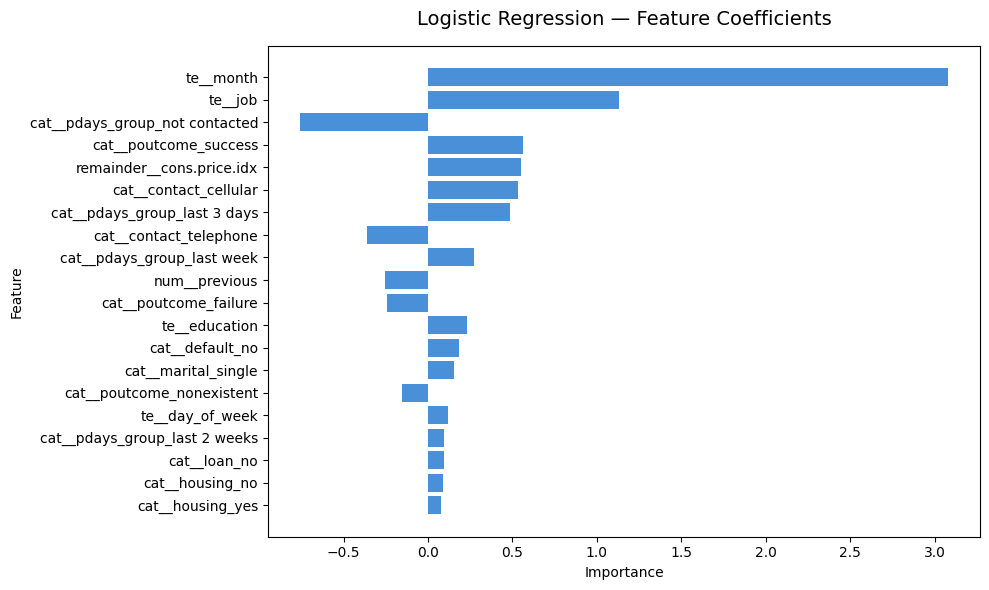

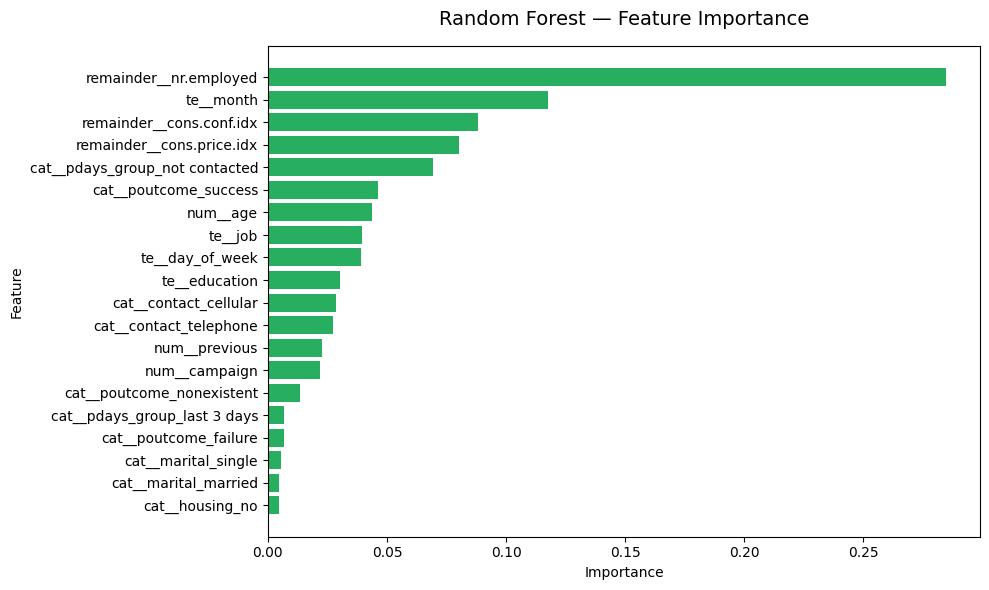

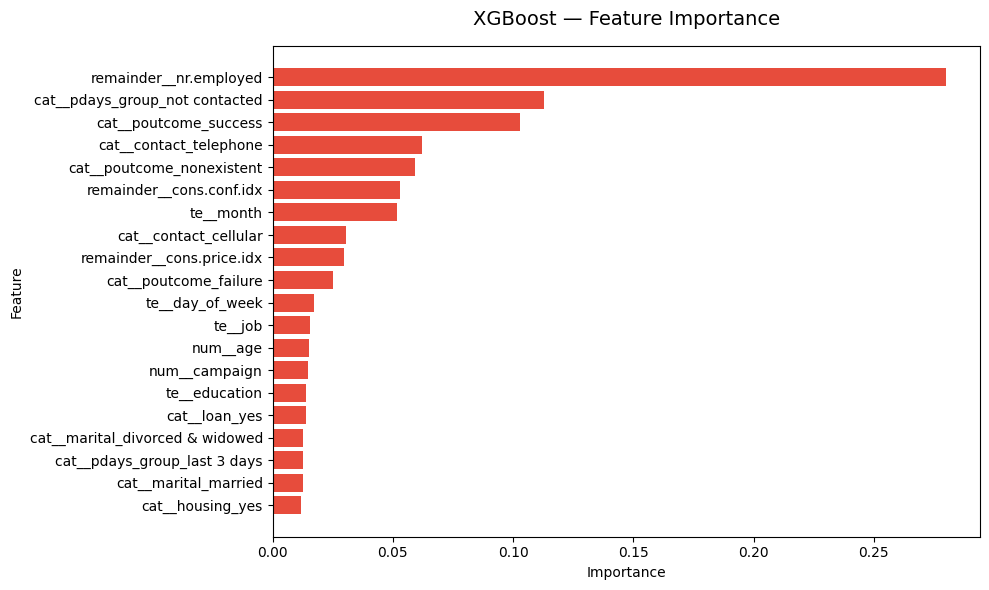

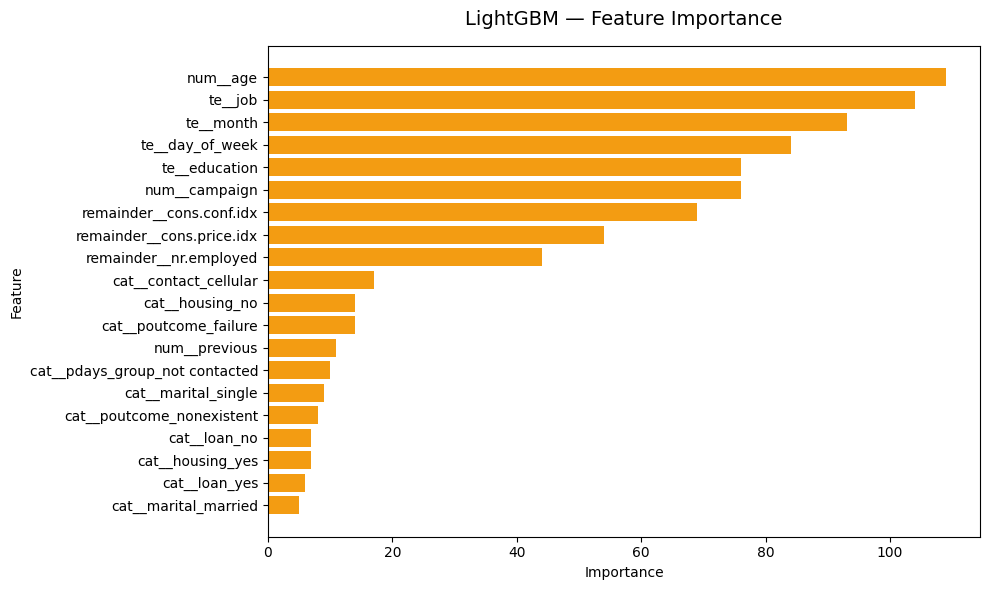

In [ ]:
def plot_feature_importance(importances, feature_names, title, color, top_n=20):
    df_imp = pd.DataFrame({"feature": feature_names, "importance": importances})
    df_imp = df_imp.reindex(df_imp["importance"].abs().sort_values(ascending=False).index)
    df_imp = df_imp.head(top_n)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(df_imp["feature"][::-1], df_imp["importance"][::-1], color=color)
    ax.set_title(title, fontsize=14, pad=15)
    ax.set_xlabel("Importance")
    ax.set_ylabel("Feature")
    plt.tight_layout()
    plt.show()

# ── Feature names from the full preprocessor ─────────────
feature_names = preprocessor.get_feature_names_out().tolist()

# ── Logistic Regression ───────────────────────────────────
plot_feature_importance(
    importances  = lr_best.named_steps['classifier'].coef_[0],       # ← replace with your actual LR model variable
    feature_names= feature_names,
    title        = "Logistic Regression — Feature Coefficients",
    color        = "#4A90D9"
)

# ── Random Forest ─────────────────────────────────────────
plot_feature_importance(
    importances  = rf_best.named_steps['classifier'].feature_importances_,   # ← replace with your actual RF model variable
    feature_names= feature_names,
    title        = "Random Forest — Feature Importance",
    color        = "#27AE60"
)

# ── XGBoost ───────────────────────────────────────────────
plot_feature_importance(
    importances  = xgb_best.named_steps['classifier'].feature_importances_,  # ← replace with your actual XGB model variable
    feature_names= feature_names,
    title        = "XGBoost — Feature Importance",
    color        = "#E74C3C"
)

# ── LightGBM ──────────────────────────────────────────────
plot_feature_importance(
    importances  = lgbm_best.named_steps['classifier'].feature_importances_, # ← replace with your actual LGBM model variable
    feature_names= feature_names,
    title        = "LightGBM — Feature Importance",
    color        = "#F39C12"
)